# Final Database Assembly and Validation

This notebook assembles the final national building and industrial-site databases from the completed classification workflow. It retains the attributes required for downstream applications and evaluates the resulting building distributions against available national reference statistics.

**Input**
- Final classified building data.
- Industrial parent-site data produced by the industrial grouping workflow.
- National reference statistics used for external comparison.

**Output**
- Final building-level classification database.
- Final industrial-site database.
- National classification summaries and external validation results.

In [27]:
import pandas as pd
import geopandas as gpd
import os

ROOT_DIR = '/fast/home/o-olajuyigbe/osm_project'
DATA_DIR = os.path.join(ROOT_DIR, 'data')
OUT_DIR  = os.path.join(DATA_DIR, 'final')

BUILDING_FILE = os.path.join(OUT_DIR, 'germany_buildings_with_parent_id.parquet')
PARENT_FILE   = os.path.join(OUT_DIR, 'germany_industrial_parents.parquet')
FINAL_CLASSIFIED_FILE = os.path.join(OUT_DIR, 'germany_final_classified_building_database.parquet')
FINAL_IND_SITE = os.path.join(OUT_DIR, 'germany_final_classified_industrial_sites.parquet')

In [28]:
# Load the classification + grouping output
gdf_bldg = gpd.read_parquet(BUILDING_FILE)
print(f"Loaded buildings: {gdf_bldg.shape}")
gdf_bldg.sample(5)

Loaded buildings: (38802372, 22)


,id,final_l1,final_l2,l1_confidence,l2_confidence,label_source,geometry,raw_label,landuse_l1,landuse_l2,...,area,is_abandoned,manmade_osm_id,man_made,manmade_category,parent_id,ind_mapped_subtype,parent_subtype,parent_subtype_source,parent_subtype_evidence
15223121,895247308,residential,SFH,0.999204,0.981172,ml_predicted,"POLYGON ((12.01436 48.45853, 12.01444 48.45851...",None,residential,None,...,72.437590,False,<NA>,None,None,<NA>,None,None,None,None
35583155,256330460,filter,None,NaN,NaN,excluded,"POLYGON ((11.03221 49.59098, 11.03224 49.59098...",roof,residential,None,...,7.357615,False,<NA>,None,None,<NA>,None,None,None,None
17550800,1220997839,residential,SFH,0.979288,0.775263,ml_predicted,"POLYGON ((7.31012 50.44656, 7.31029 50.44659, ...",None,None,None,...,286.192170,False,<NA>,None,None,<NA>,None,None,None,None
13871770,715675237,industrial,storage,0.589509,0.779284,ml_predicted,"POLYGON ((11.18867 54.44042, 11.18881 54.44041...",None,commercial,None,...,79.111537,False,<NA>,None,None,BLDG_715675237,None,storage,standalone_final_l2,storage
18115584,1444739229,other,None,0.880336,NaN,ml_predicted,"POLYGON ((14.96185 51.33138, 14.96193 51.33138...",None,None,None,...,89.549806,False,<NA>,None,None,<NA>,None,None,None,None


In [29]:
gdf_bldg.is_abandoned.value_counts(dropna=False)

is_abandoned
False    38776106
True        26266
Name: count, dtype: int64

In [30]:

# Define the final energy-modeling column set explicitly
#    Split into tiers so it's clear what's core vs optional/audit
CORE_COLS = [
    'id', 'geometry', 'final_l1', 'final_l2', 'parent_id', 'parent_subtype', 'area', 'is_abandoned'
]

PROVENANCE_COLS = [
    'l1_confidence', 'l2_confidence', 'label_source'
]  # keep for validation/QA, may drop from the "slim" production file

FINAL_COLS = CORE_COLS + PROVENANCE_COLS
FINAL_COLS = [c for c in FINAL_COLS if c in gdf_bldg.columns]

gdf_final = gdf_bldg[FINAL_COLS].copy()
print(f"Final building table: {gdf_final.shape}, columns: {list(gdf_final.columns)}")


Final building table: (38802372, 11), columns: ['id', 'geometry', 'final_l1', 'final_l2', 'parent_id', 'parent_subtype', 'area', 'is_abandoned', 'l1_confidence', 'l2_confidence', 'label_source']


In [31]:
# Load parent (industrial site) table - this is what carries the load per site

gdf_parents = gpd.read_parquet(PARENT_FILE)
PARENT_COLS = [
    'parent_id', 'landuse_geometry', 'subtype', 'total_area',
    'n_buildings', 'n_industrial_buildings',  'parent_type',
]
PARENT_COLS = [c for c in PARENT_COLS if c in gdf_parents.columns]
gdf_parents_final = gdf_parents[PARENT_COLS].copy()


In [32]:
# Save
gdf_final.to_parquet(FINAL_CLASSIFIED_FILE, index=False)
gdf_parents_final.to_parquet(FINAL_IND_SITE, index=False)
print("Saved final energy-modeling input tables.")

Saved final energy-modeling input tables.


In [33]:
print("=" * 60)
print("NATIONAL BUILDING COUNT SUMMARY — GERMANY")
print("=" * 60)

# ── L1 counts ─────────────────────────────────────────────────────────────────
l1_counts = gdf_bldg['final_l1'].value_counts()
l1_total  = l1_counts.sum()
print(f"\n{'Building Type':<25} {'Count':>12} {'%':>8}")
print("-" * 47)
for typ, cnt in l1_counts.items():
    print(f"{str(typ):<25} {cnt:>12,} {cnt/l1_total*100:>7.2f}%")
print(f"{'TOTAL':<25} {l1_total:>12,}")

# ── L1 × L2 cross-table ───────────────────────────────────────────────────────
print(f"\n{'Building Type':<20} {'Subtype':<30} {'Count':>12} {'%':>8}")
print("-" * 72)
l1l2_counts = gdf_bldg.groupby(['final_l1', 'final_l2'], dropna=False, observed=True).size()
for (l1, l2), cnt in l1l2_counts.sort_values(ascending=False).items():
    l2_str = str(l2) if pd.notna(l2) else '(no subtype)'
    print(f"{str(l1):<20} {l2_str:<30} {cnt:>12,} {cnt/l1_total*100:>7.2f}%")


NATIONAL BUILDING COUNT SUMMARY — GERMANY

Building Type                    Count        %
-----------------------------------------------
residential                 20,641,552   53.20%
filter                       9,822,755   25.31%
other                        4,647,885   11.98%
commercial                   1,658,467    4.27%
industrial                     965,940    2.49%
civic                          370,217    0.95%
semi_commercial                350,126    0.90%
agricultural                   313,609    0.81%
transportation                  22,301    0.06%
military                         9,520    0.02%
TOTAL                       38,802,372

Building Type        Subtype                               Count        %
------------------------------------------------------------------------
residential          SFH                              15,372,510   39.62%
filter               (no subtype)                      9,822,725   25.31%
other                (no subtype)             

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams.update({
    "figure.dpi":400,"font.size":11,"axes.titlesize":15,"axes.labelsize":11,
    "axes.titleweight":"bold","axes.spines.top":False,"axes.spines.right":False,
    "axes.edgecolor":"#444444","figure.facecolor":"white","axes.facecolor":"white",
    "legend.frameon":False
})

COLORS={"blue":"#2A6F97","magenta":"#A23B72","orange":"#E07A5F",
        "red":"#C8553D","green":"#4C956C","grey":"#AAB7C2"}

def clean(x): return str(x).replace("_"," ").title()

def compact(v):
    if abs(v)>=1e6: return f"{v/1e6:.2f}M"
    if abs(v)>=1e3: return f"{v/1e3:.0f}K"
    return f"{v:,.0f}"

def header(fig,title,subtitle=None):
    fig.suptitle(title,x=.07,y=.97,ha="left",fontsize=16,fontweight="bold")
    if subtitle:
        fig.text(.07,.89,subtitle,fontsize=10,color="#555555")

def composition_chart(counts,title,subtitle="",cmap="Blues",xlabel="Building count"):
    s=pd.Series(counts).loc[lambda x:x>0].sort_values()
    shares=s/s.sum()*100
    colors=getattr(plt.cm,cmap)(np.linspace(.45,.85,len(s)))

    fig,ax=plt.subplots(figsize=(9,5.3))
    fig.subplots_adjust(left=.25,right=.95,top=.86,bottom=.15)
    bars=ax.barh([clean(x) for x in s.index],s.values,color=colors,height=.62)

    for bar,value,share in zip(bars,s.values,shares.values):
        ax.text(value+s.max()*.012, bar.get_y()+bar.get_height()/2,
            f"{value:,.0f}  |  {share:.1f}%",
            va="center",ha="left",fontsize=10,fontweight="bold")

    header(fig,title,subtitle)
    ax.set_xlabel(xlabel)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f"{v/1e6:.1f}M" if v>=1e6
            else f"{v/1e3:.0f}K" if v>=1e3 else f"{v:,.0f}"))
    ax.set_xlim(0,s.max()*1.32)
    ax.grid(axis="x",alpha=.16)
    ax.set_axisbelow(True)
    plt.show()

def ratio_chart(title,subtitle,labels,ratios,details,xlabel,note,digits=2):
    y=np.array([1,0])
    fig,ax=plt.subplots(figsize=(10,4.8))
    fig.subplots_adjust(left=.22,right=.96,top=.85,bottom=.22)
    bars=ax.barh(y,ratios,height=.38,color=[COLORS["blue"],COLORS["orange"]])
    offset=max(ratios)*.03

    for bar,ratio,detail in zip(bars,ratios,details):
        ax.text(ratio+offset,bar.get_y()+bar.get_height()/2,
                f"{ratio:.{digits}f} : 1",va="center",fontsize=12,fontweight="bold")
        ax.text(.01,bar.get_y()-.08,detail,va="top",fontsize=9,color="#555555")

    header(fig,title,subtitle)
    ax.set_yticks(y,labels)
    ax.set_xlim(0,max(ratios)*1.38)
    ax.set_ylim(-.42,1.42)
    ax.set_xlabel(xlabel)
    ax.grid(axis="x",alpha=.15)
    ax.tick_params(axis="y",length=0)
    ax.set_axisbelow(True)
    fig.text(.07,.05,note,fontsize=8.7,color="#666666")
    plt.show()

In [35]:
# Extract model counts

required={"final_l1","final_l2"}
missing=required-set(gdf_bldg.columns)
if missing: raise KeyError(f"Missing columns: {sorted(missing)}")

model_l1=gdf_bldg["final_l1"].value_counts()

def subtype_counts(l1):
    return gdf_bldg.loc[gdf_bldg["final_l1"].eq(l1),"final_l2"].fillna("unclassified").value_counts().to_dict()

model_res=subtype_counts("residential")
model_comm=subtype_counts("commercial")
model_ind=subtype_counts("industrial")
model_sc=subtype_counts("semi_commercial")

model_res_total=sum(model_res.values())
model_comm_total=sum(model_comm.values())
model_ind_total=sum(model_ind.values())
model_sc_total=sum(model_sc.values())

print(f"Total: {len(gdf_bldg):,}")
print(f"Residential: {model_res_total:,}")
print(f"Commercial: {model_comm_total:,}")
print(f"Industrial: {model_ind_total:,}")
print(f"Semi-Commercial: {model_sc_total:,}")

Total: 38,802,372
Residential: 20,641,552
Commercial: 1,658,467
Industrial: 965,940
Semi-Commercial: 350,126


In [36]:
# Reference statistics

zensus_raw = {
    "detached_sfh": 8665544, "semi_sfh": 2202687, "terraced_sfh": 2141975,
    "detached_2fam": 2123381, "semi_2fam": 305821, "terraced_2fam": 268627,
    "mfh_3_6": 2287349, "mfh_7_12": 921714, "mfh_13plus": 237550, "other": 802622,
}
zensus_form = {
    "SFH": zensus_raw["detached_sfh"] + zensus_raw["semi_sfh"] + zensus_raw["detached_2fam"]
           + zensus_raw["semi_2fam"] + zensus_raw["other"],
    "TH":  zensus_raw["terraced_sfh"] + zensus_raw["terraced_2fam"],
    "MFH": zensus_raw["mfh_3_6"] + zensus_raw["mfh_7_12"] + zensus_raw["mfh_13plus"],
}
zensus_total = sum(zensus_raw.values())

wz08={
    "C_manufacturing":220_606,
    "G_wholesale_retail":659_860,
    "I_accommodation_food":261_672,
    "J_information_communication":155_067,
    "K_financial_insurance":95_842,
    "L_real_estate":246_287,
    "M_professional_scientific_technical":553_376,
    "N_administrative_support":270_471
}

print(f"Zensus residential total: {zensus_total:,}")
print(pd.Series(zensus_form))

Zensus residential total: 19,957,270
SFH    14100055
TH      2410602
MFH     3446613
dtype: int64


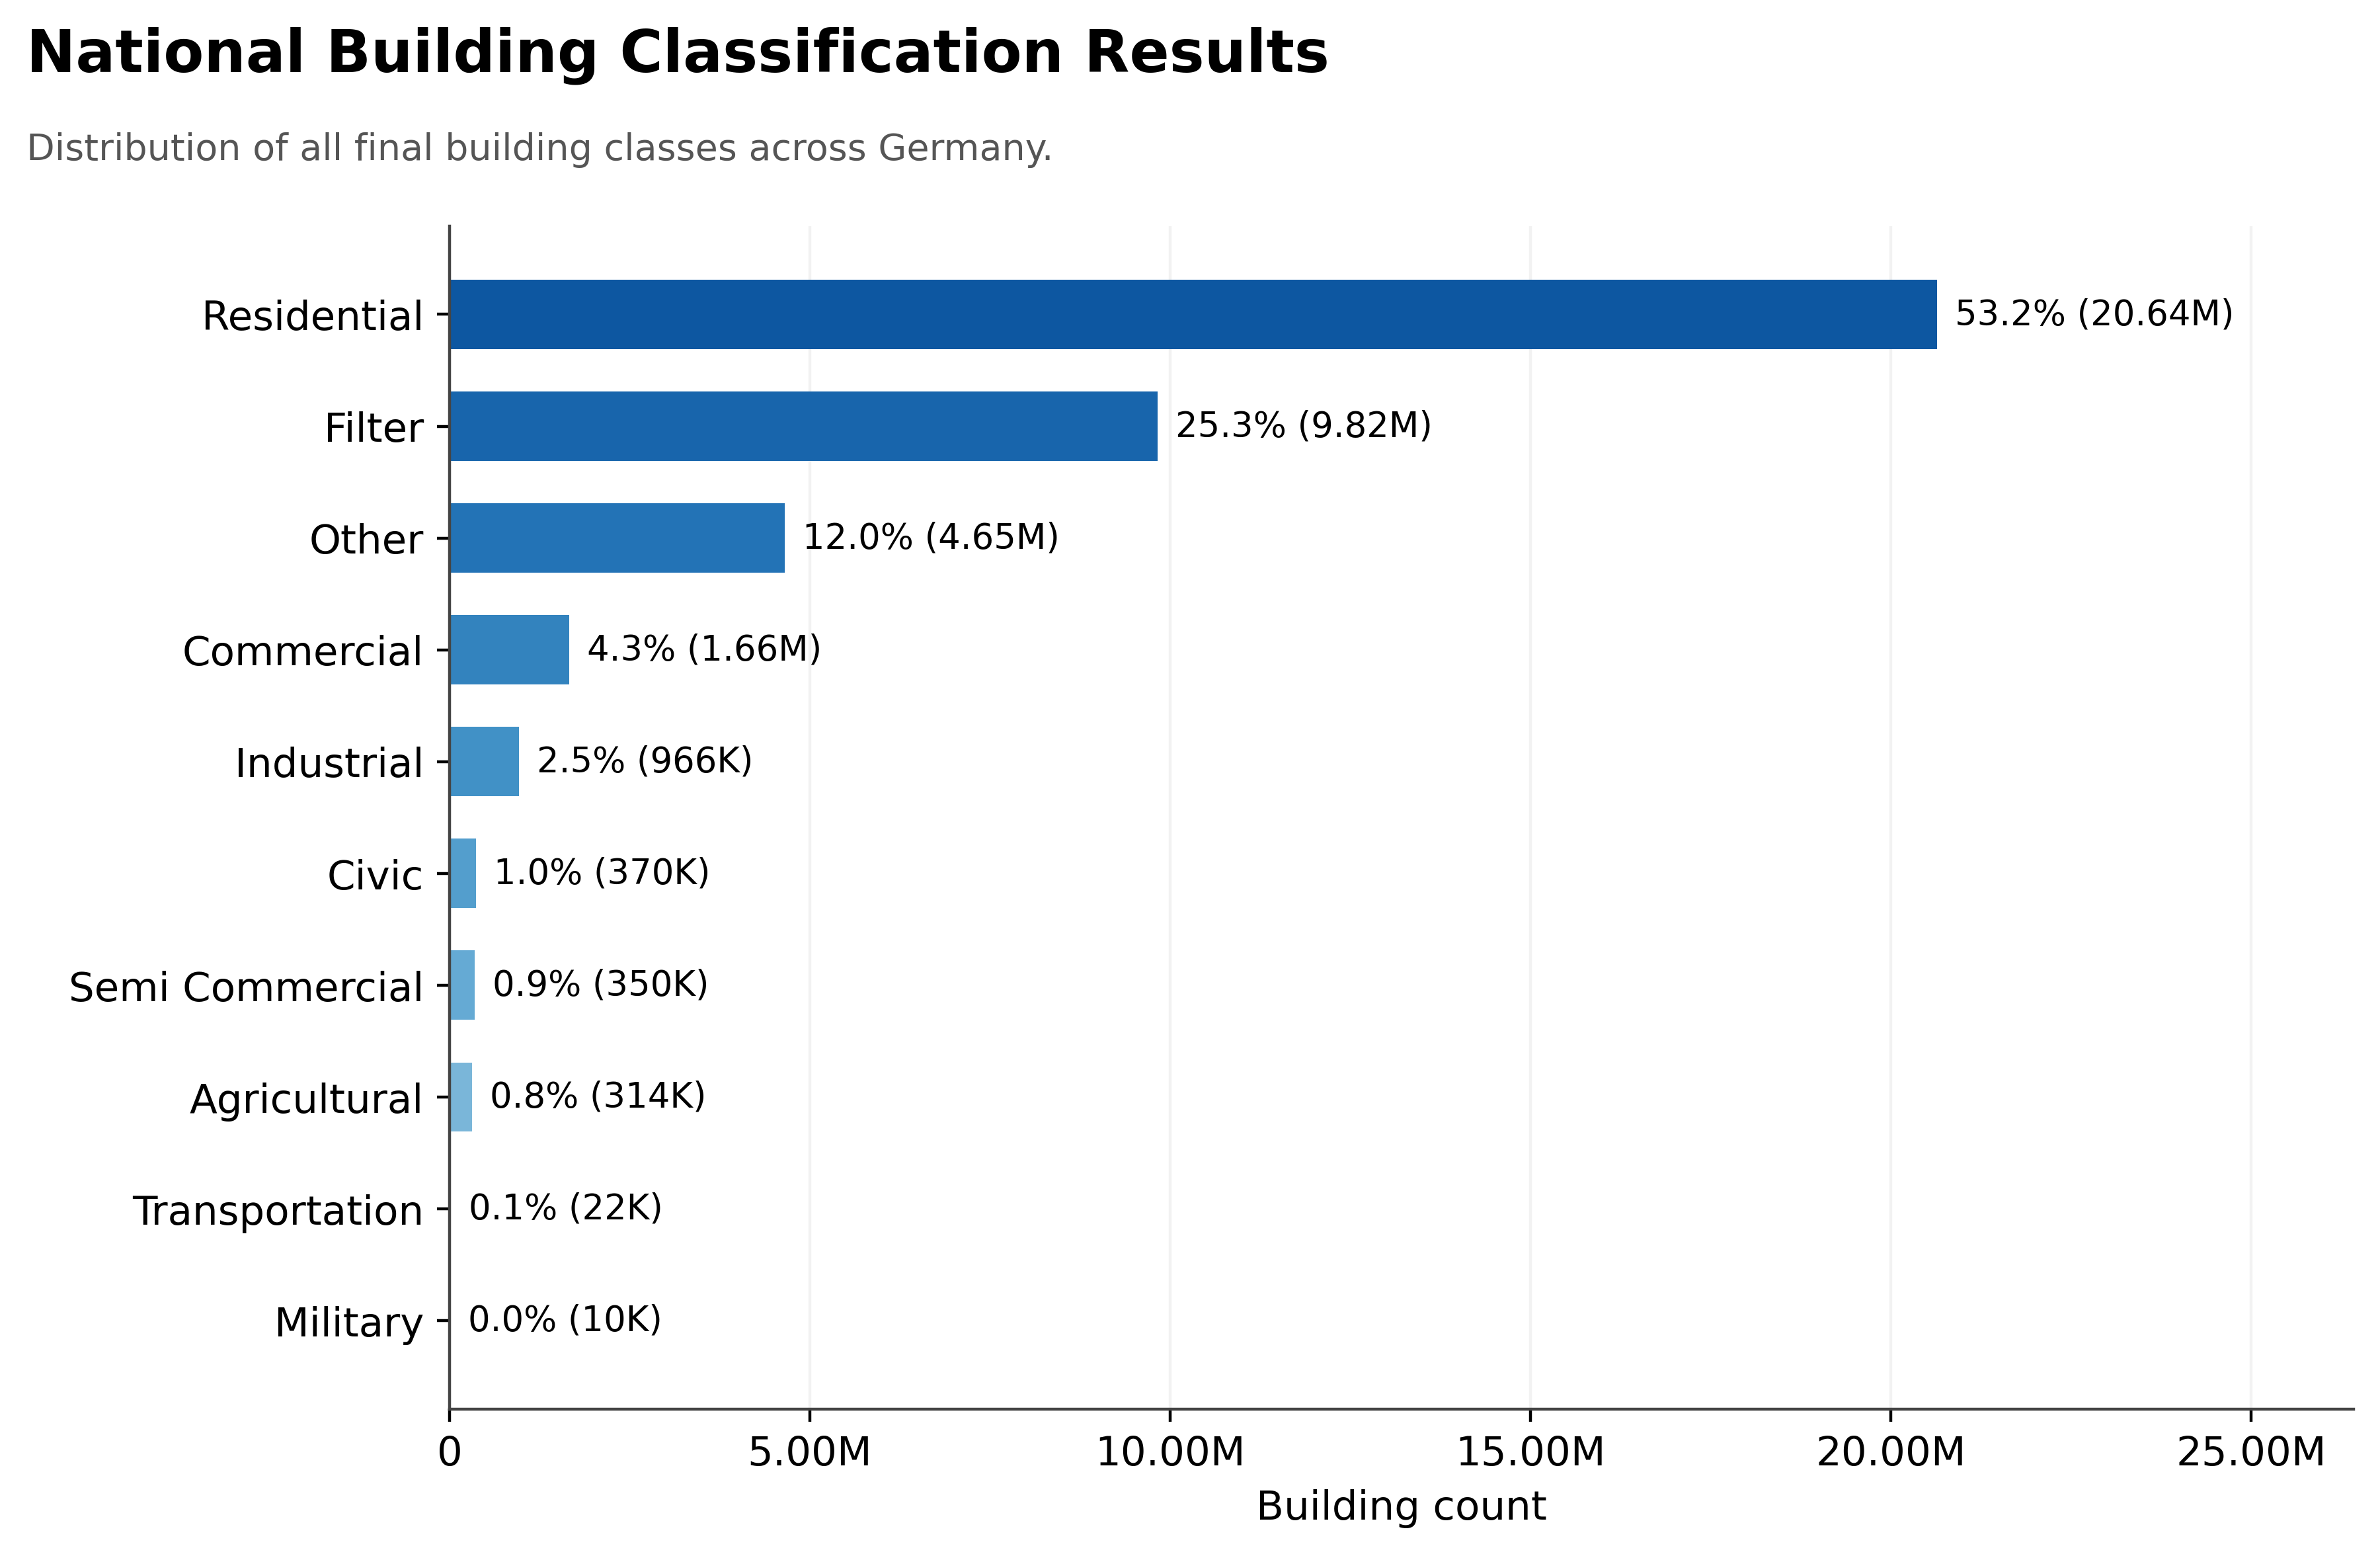

In [37]:
counts=model_l1.sort_values()
shares=counts/counts.sum()*100

fig,ax=plt.subplots(figsize=(10,6.3))
fig.subplots_adjust(left=.23,right=.95,top=.85,bottom=.14)

bars=ax.barh([clean(x) for x in counts.index],counts.values,
             color=plt.cm.Blues(np.linspace(.35,.85,len(counts))),height=.62)

for bar,v,p in zip(bars,counts.values,shares.values):
    ax.text(v+counts.max()*.012,bar.get_y()+bar.get_height()/2,
            f"{p:.1f}% ({compact(v)})",va="center",fontsize=9.5)

header(fig,"National Building Classification Results",
       "Distribution of all final building classes across Germany.")

ax.set_xlabel("Building count")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_:compact(v)))
ax.set_xlim(0,counts.max()*1.28)
ax.grid(axis="x",alpha=.16)
ax.set_axisbelow(True)
plt.show()

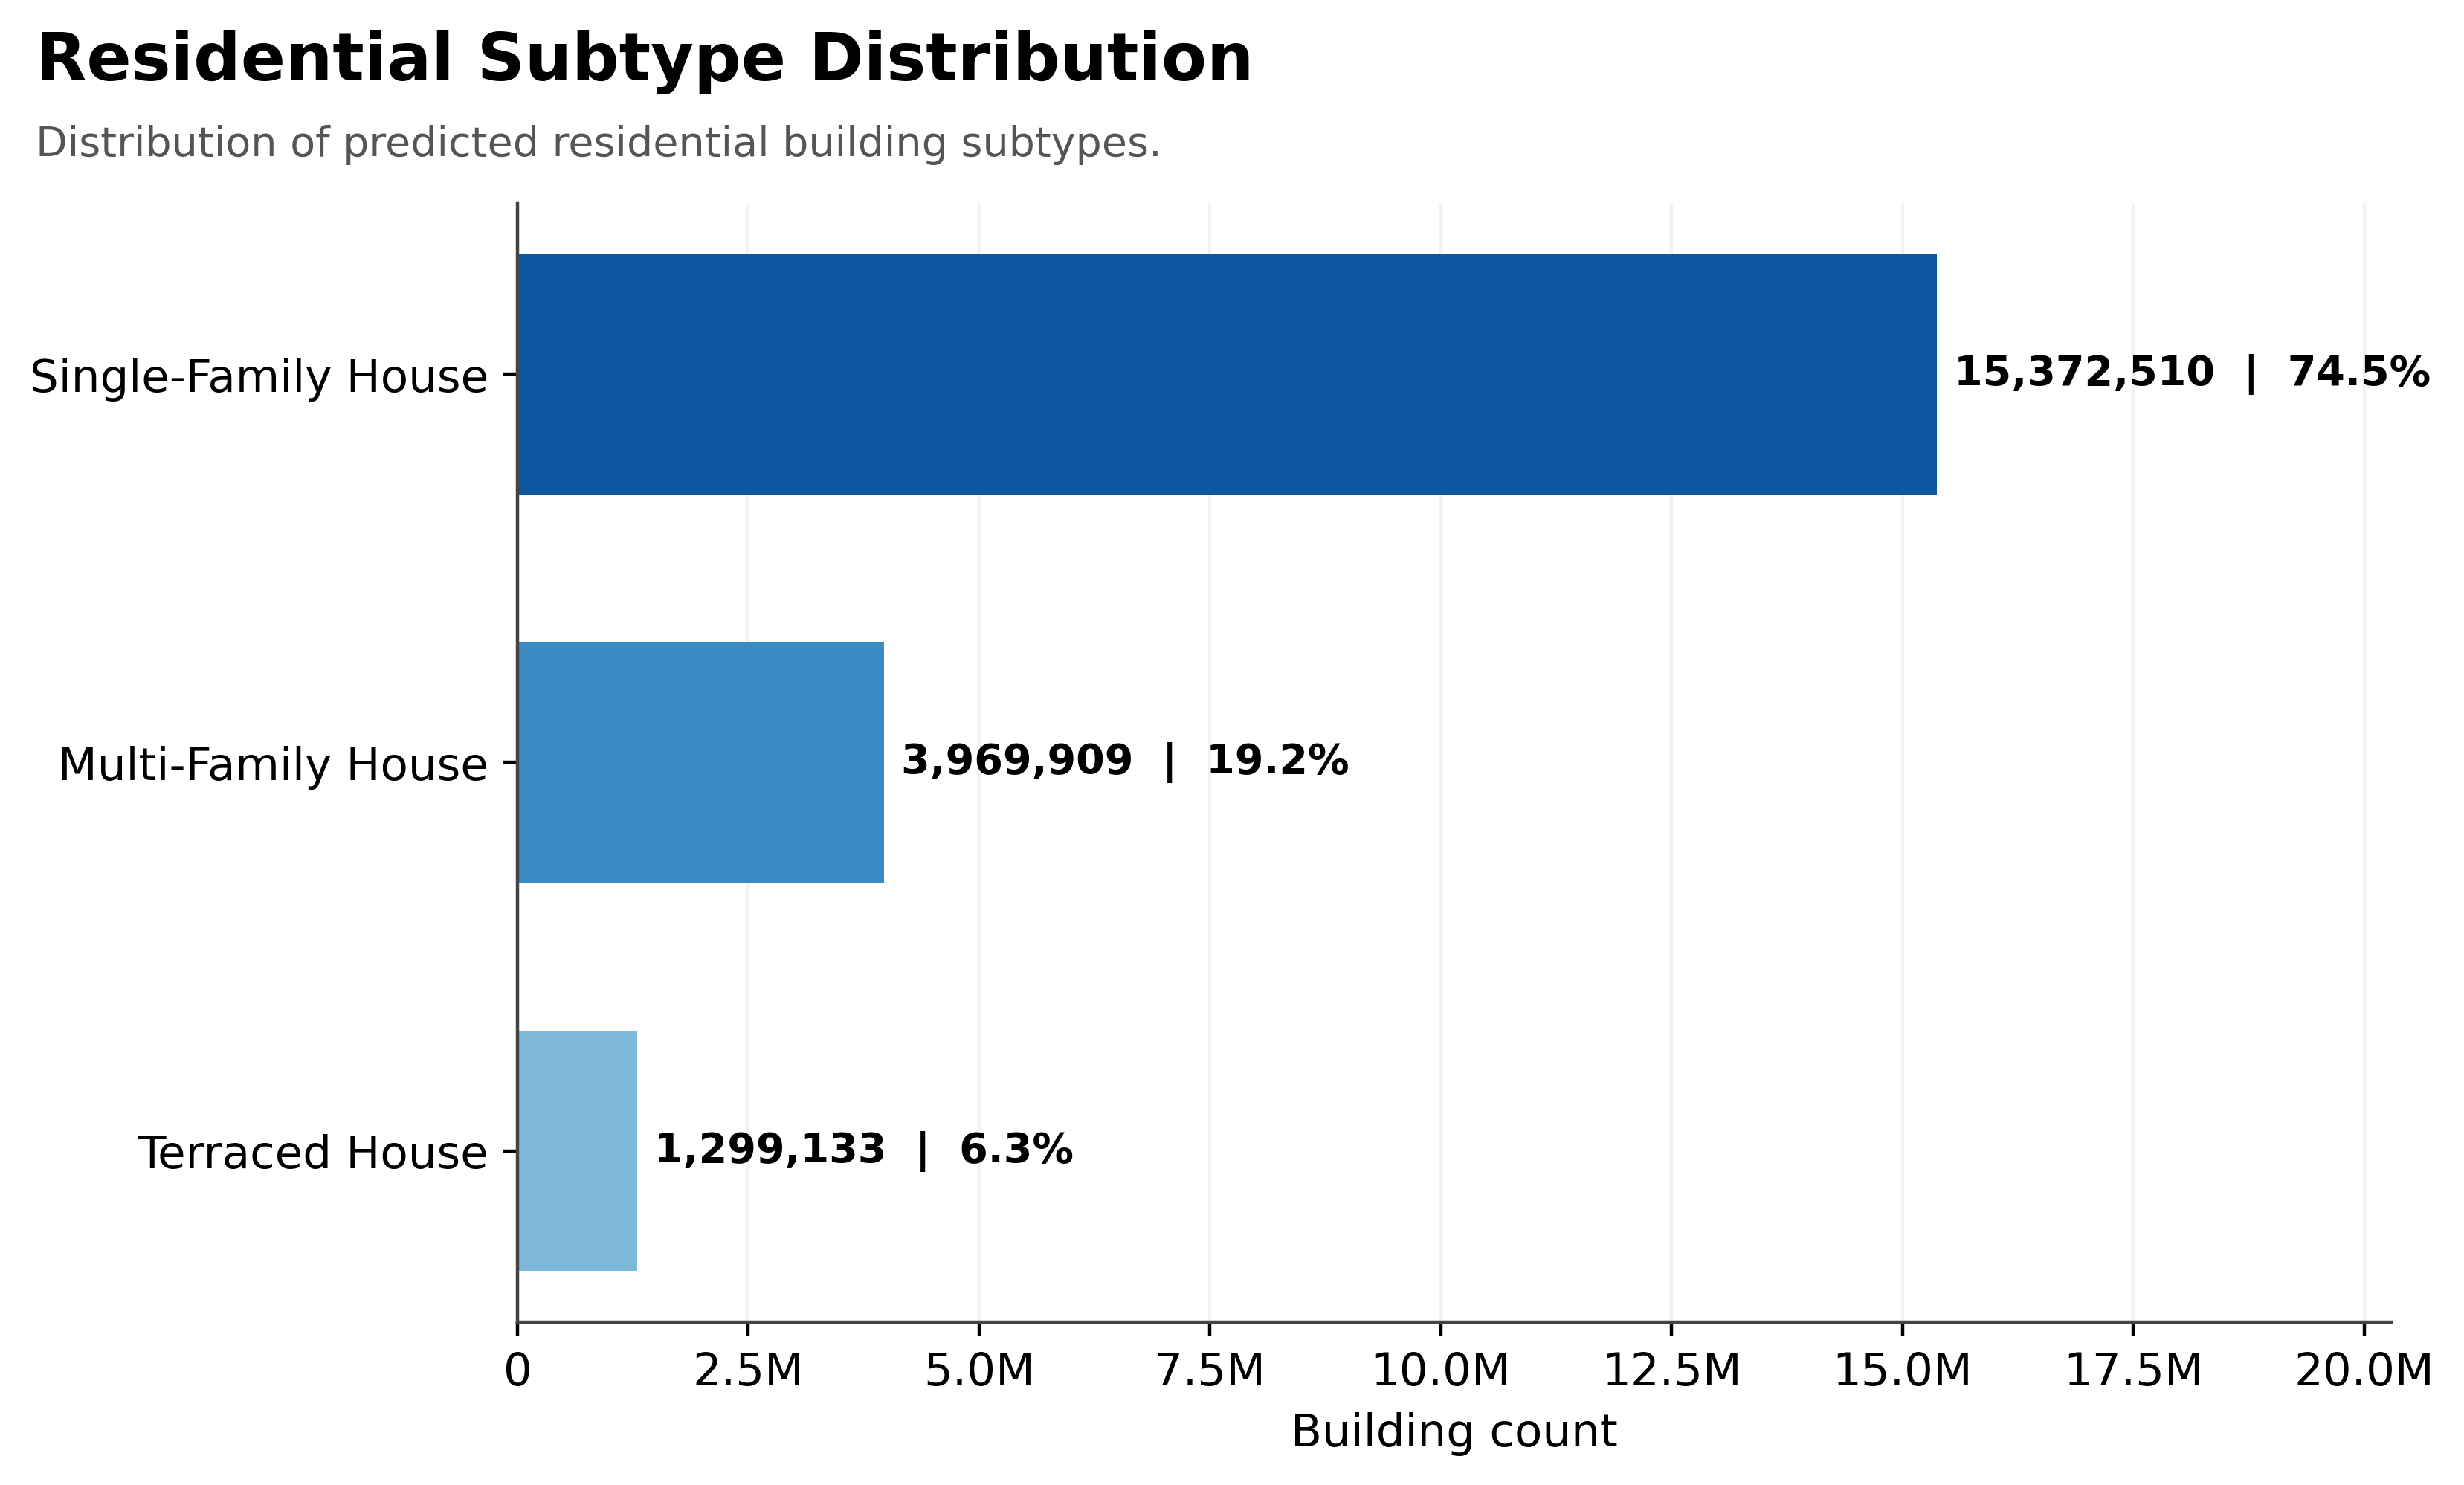

In [38]:
# Residential composition

composition_chart(
    {"Single-family house":model_res.get("SFH",0),
     "Terraced house":model_res.get("TH",0),
     "Multi-family house":model_res.get("MFH",0)},
    "Residential Subtype Distribution",
    "Distribution of predicted residential building subtypes."
)

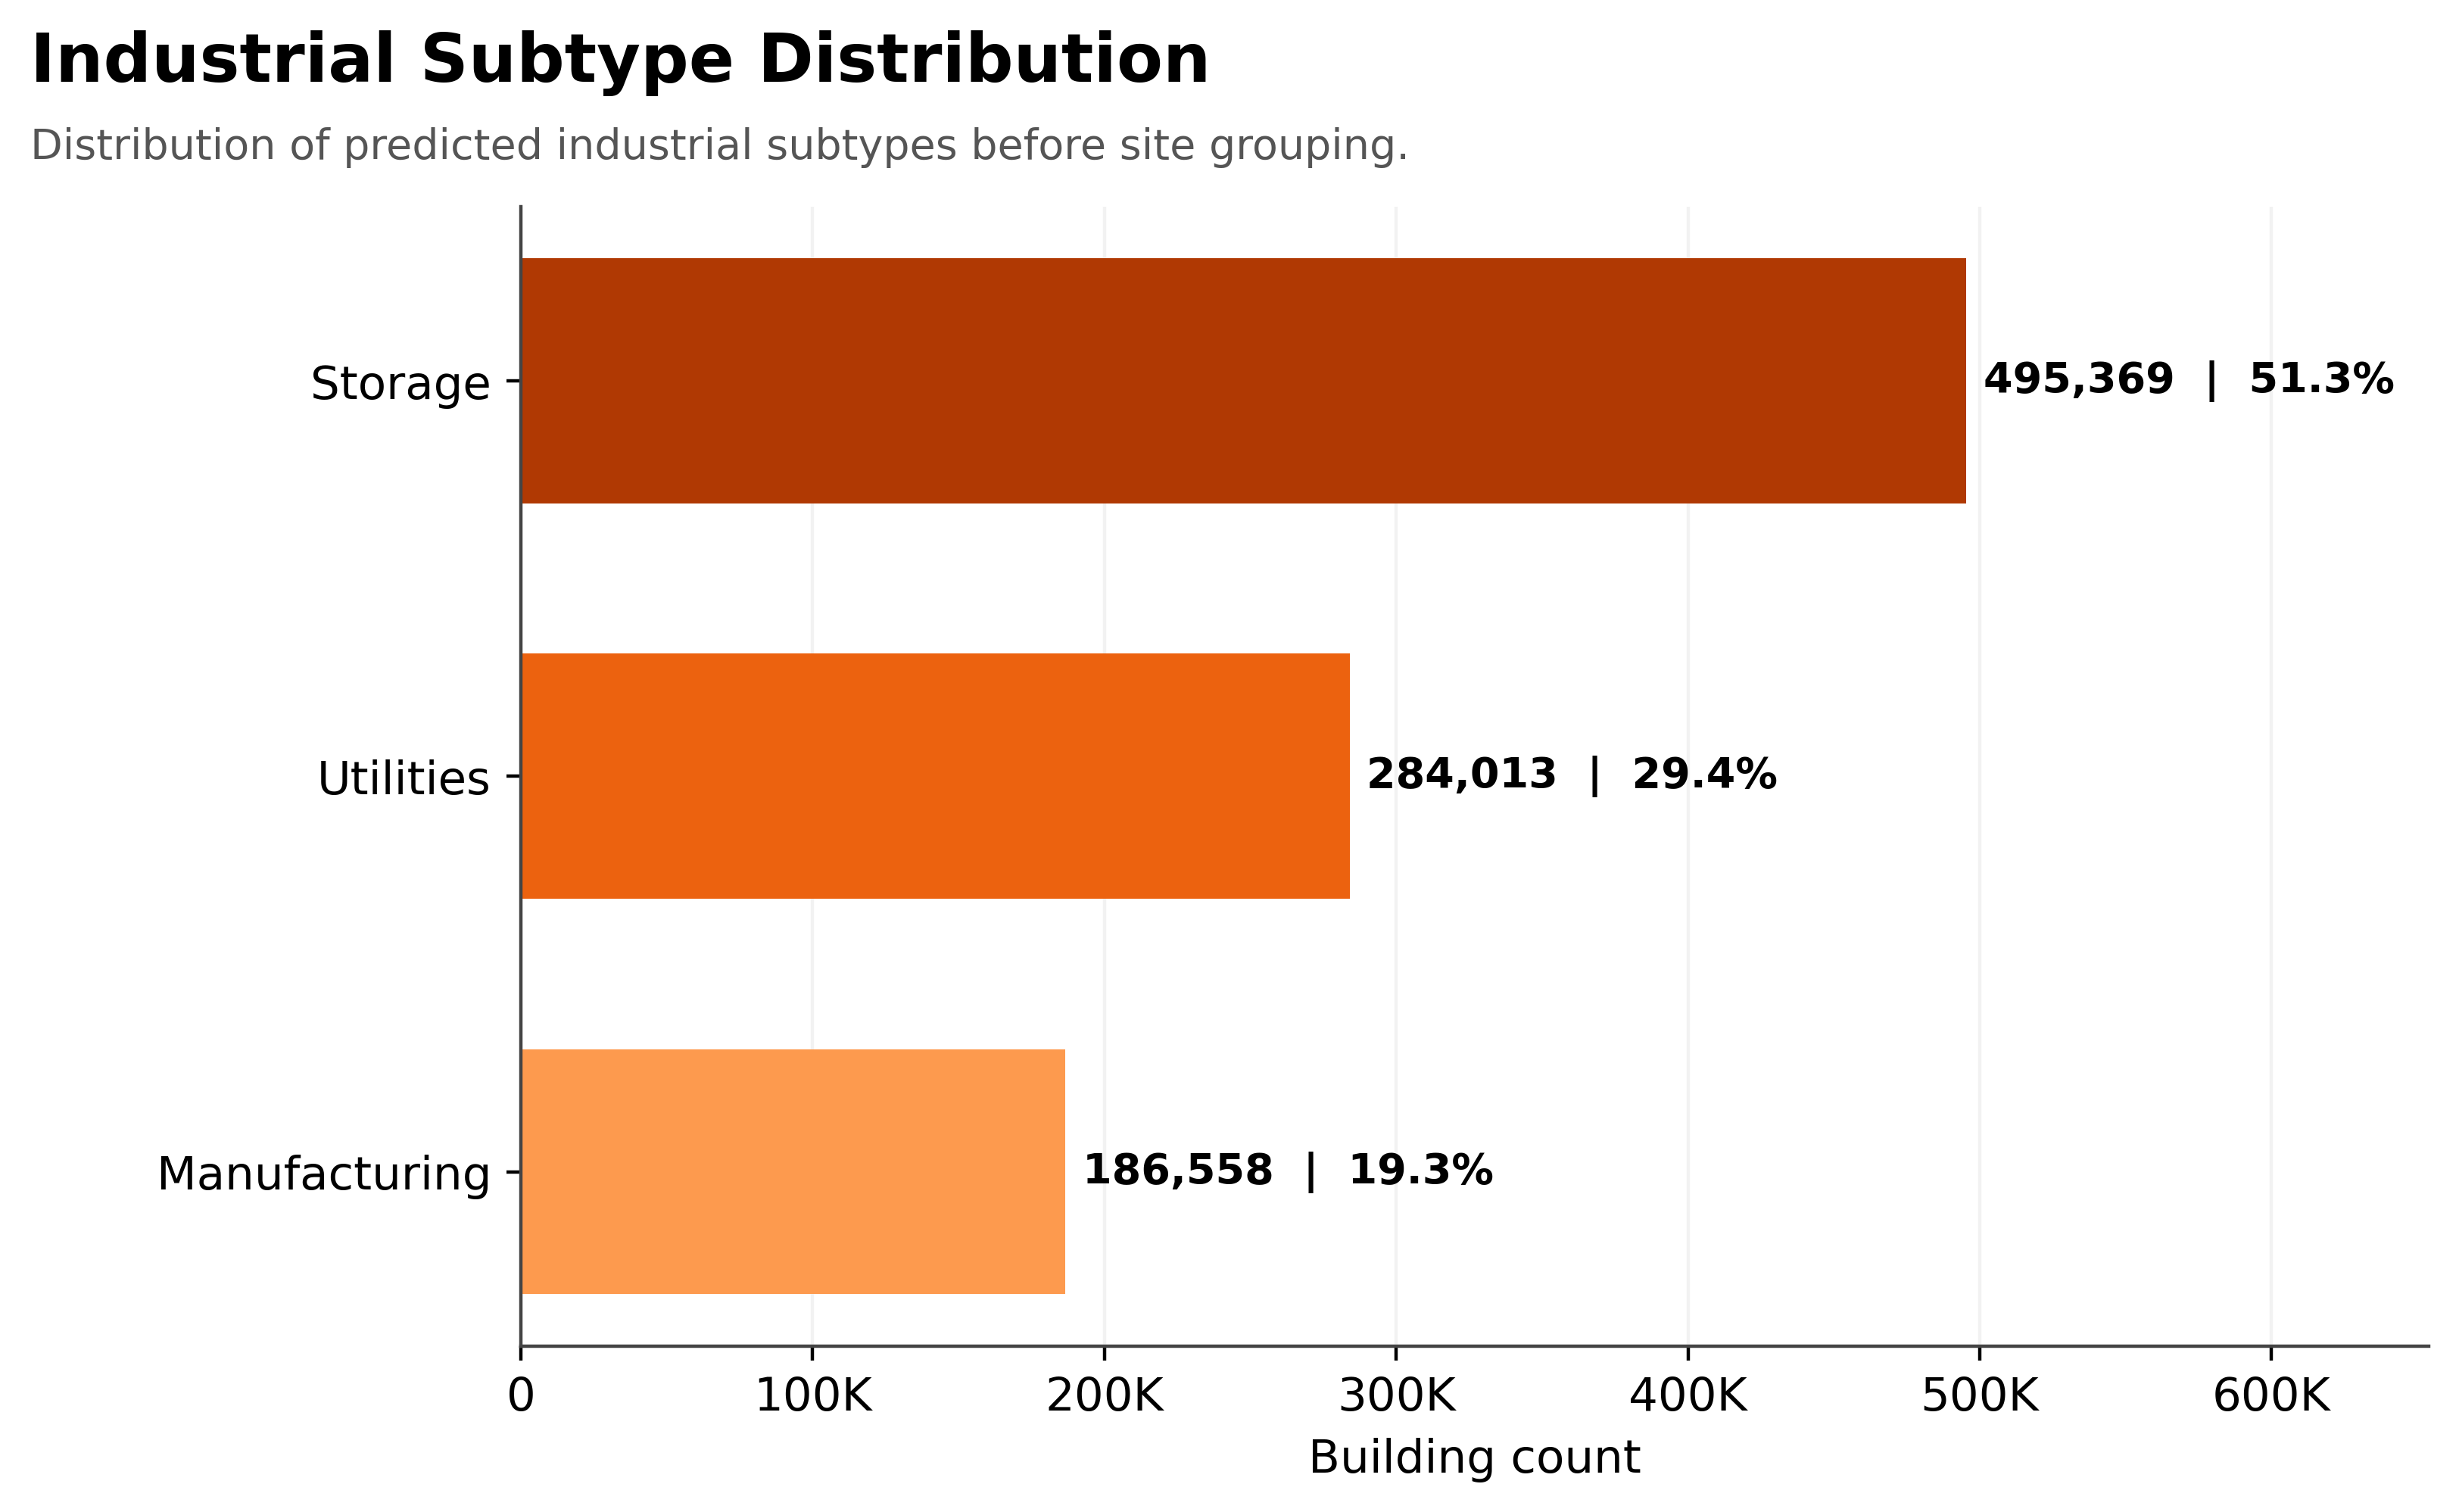

In [39]:
composition_chart(
    {"Manufacturing":model_ind.get("manufacturing",0),
     "Storage":model_ind.get("storage",0),
     "Utilities":model_ind.get("utilities",0)},
    "Industrial Subtype Distribution",
    "Distribution of predicted industrial subtypes before site grouping.",
    cmap="Oranges"
)

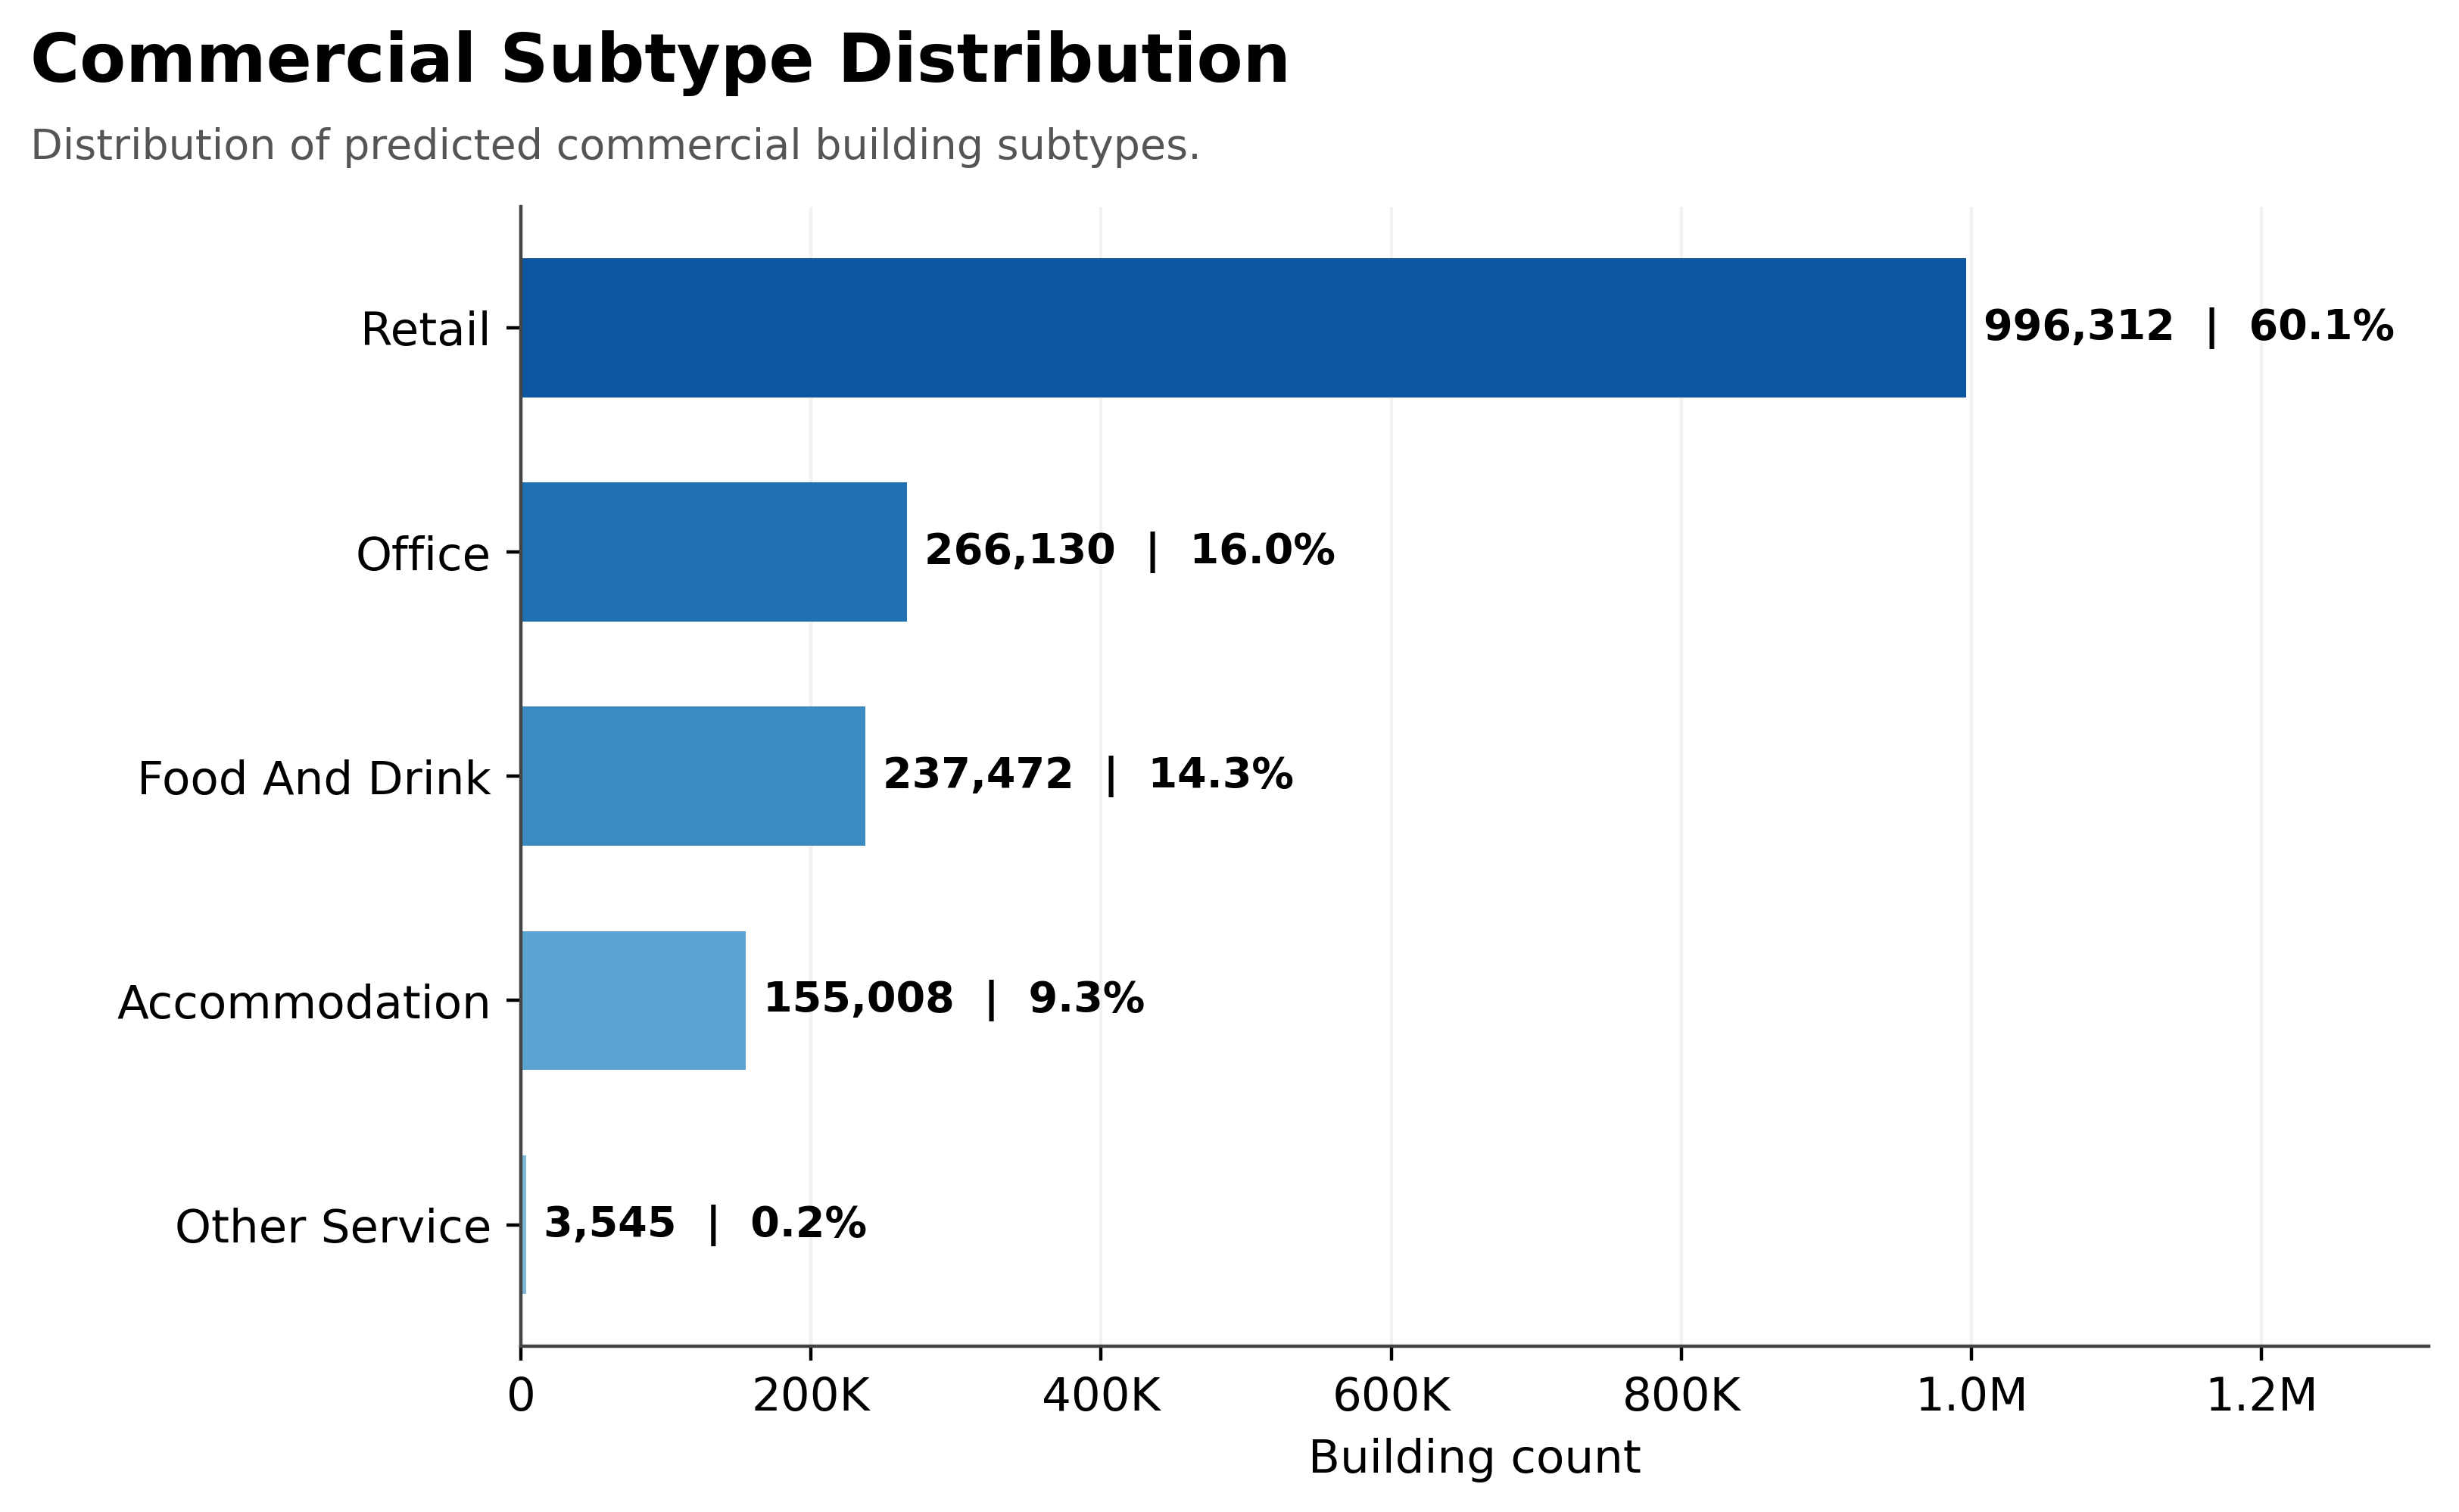

In [40]:
composition_chart(
    {"Retail":model_comm.get("retail",0),
     "Office":model_comm.get("office",0),
     "Food and drink":model_comm.get("food_drink",0),
     "Accommodation":model_comm.get("accommodation",0),
     "Other service":model_comm.get("other_service",0)},
    "Commercial Subtype Distribution",
    "Distribution of predicted commercial building subtypes."
)

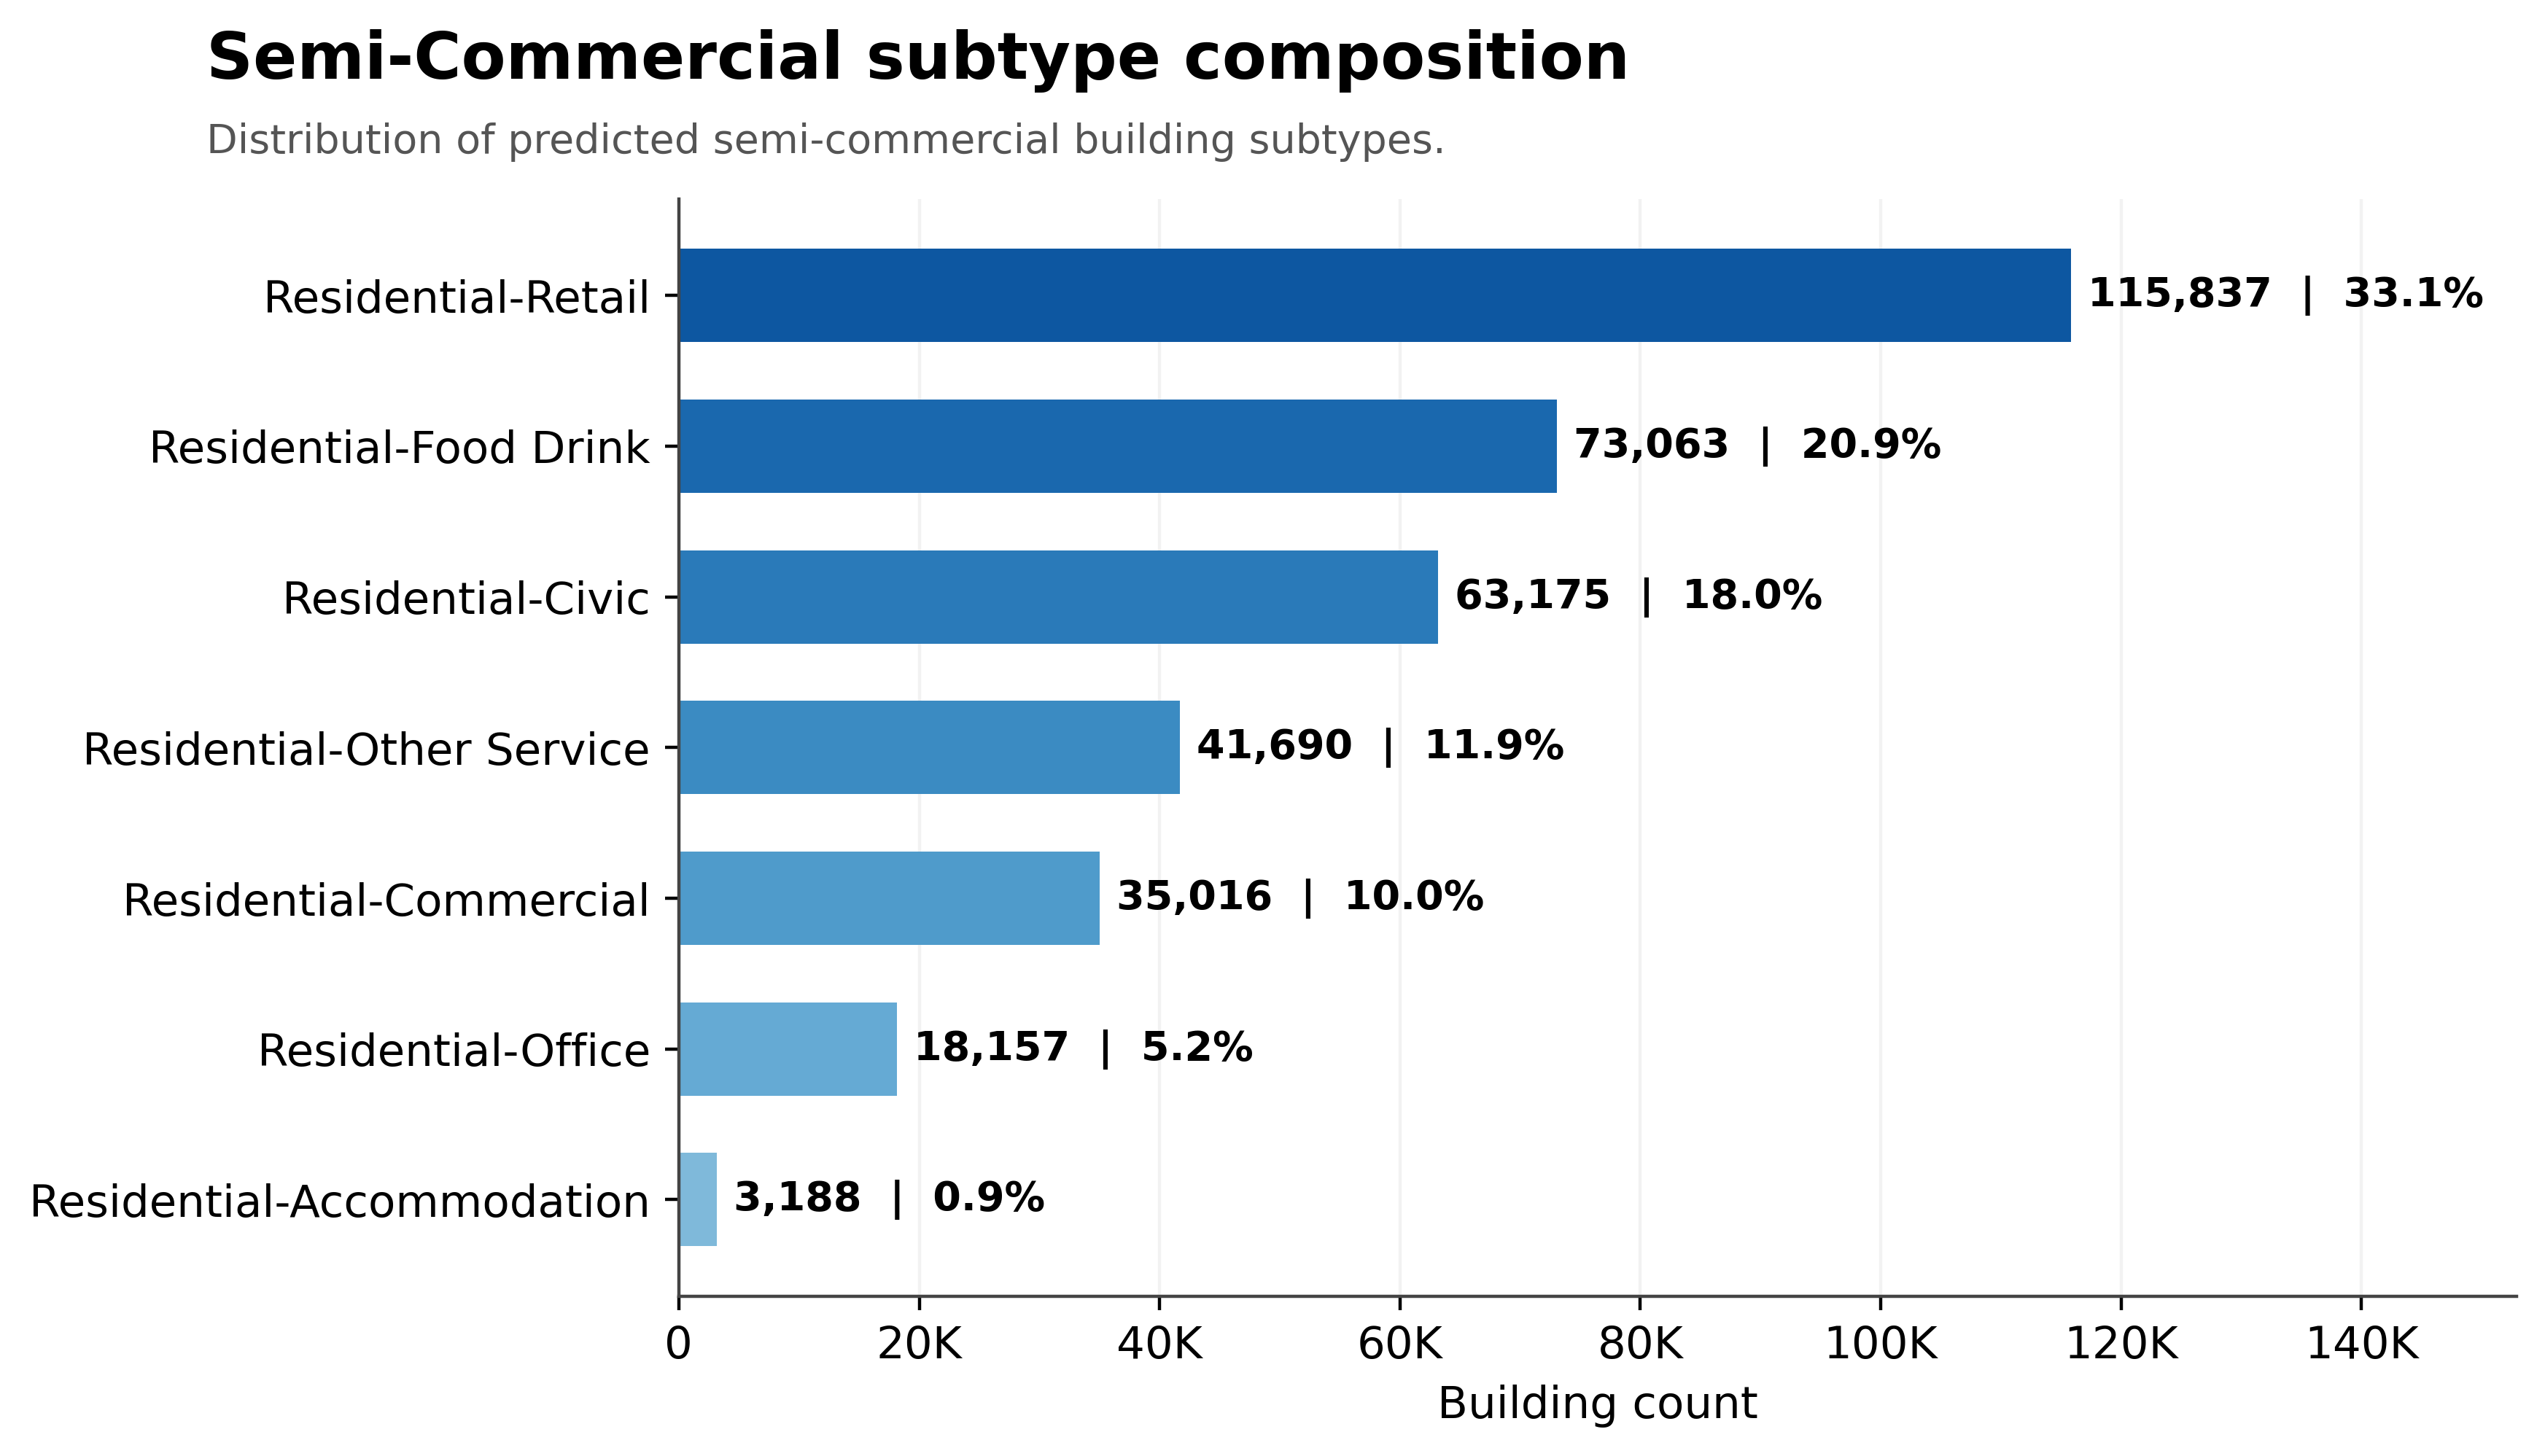

In [41]:
composition_chart(
    {"Residential-Retail":model_sc.get("residential_retail",0),
     "Residential-Office":model_sc.get("residential_office",0),
     "Residential-Food drink":model_sc.get("residential_food_drink",0),
     "Residential-Accommodation":model_sc.get("residential_accommodation",0),
     "Residential-Civic":model_sc.get("residential_civic",0),
     "Residential-Commercial":model_sc.get("residential_commercial",0),
     "Residential-Other service":model_sc.get("residential_other_service",0)},
    "Semi-Commercial subtype composition",
    "Distribution of predicted semi-commercial building subtypes."
)

In [42]:


#  RESIDENTIAL VALIDATION vs ZENSUS 2022


res_validation = pd.DataFrame([
    {"category": cat, "model": model_res.get(cat, 0), "zensus": zensus_form[cat],
     "diff": model_res.get(cat, 0) - zensus_form[cat],
     "pct_diff": round((model_res.get(cat, 0) - zensus_form[cat]) / zensus_form[cat] * 100, 1)}
    for cat in ["SFH", "TH", "MFH"]
])
print("=== Residential validation vs Zensus 2022 ===")
print(res_validation.to_string(index=False))
print(f"\nModel residential total: {model_res_total:,}   Zensus total: {zensus_total:,}   "
      f"diff: {model_res_total - zensus_total:+,} ({(model_res_total - zensus_total)/zensus_total*100:+.1f}%)")


#  NON-RESIDENTIAL: PROPORTIONAL CHECK vs WZ08 (enterprise proxy, not building counts)
model_comm = gdf_bldg[gdf_bldg['final_l1'] == 'commercial']['final_l2'].value_counts().to_dict()
model_ind = gdf_bldg[gdf_bldg['final_l1'] == 'industrial']['final_l2'].value_counts().to_dict()
model_semm_comm = gdf_bldg[gdf_bldg['final_l1'] == 'semi_commercial']['final_l2'].value_counts().to_dict()

wz08 = {
    "G_wholesale_retail": 659860, "I_accommodation_food": 261672, "C_manufacturing": 220606,
}

model_ratio = model_comm.get('retail', 0) / (model_comm.get('food_drink', 0) + model_comm.get('accommodation', 0))
wz_ratio = wz08["G_wholesale_retail"] / wz08["I_accommodation_food"]

print("\n=== Non-residential proportional check (enterprise-based proxy) ===")
print(f"Model  retail : (food+accommodation) = {model_ratio:.2f} : 1")
print(f"WZ08   retail : (food+accommodation) = {wz_ratio:.2f} : 1")
print(f"\nModel manufacturing buildings: {model_ind.get('manufacturing', 0):,}")
print(f"WZ08  manufacturing enterprises: {wz08['C_manufacturing']:,}  (coincidental proximity — different units)")

=== Residential validation vs Zensus 2022 ===
category    model   zensus     diff  pct_diff
     SFH 15372510 14100055  1272455       9.0
      TH  1299133  2410602 -1111469     -46.1
     MFH  3969909  3446613   523296      15.2

Model residential total: 20,641,552   Zensus total: 19,957,270   diff: +684,282 (+3.4%)

=== Non-residential proportional check (enterprise-based proxy) ===
Model  retail : (food+accommodation) = 2.54 : 1
WZ08   retail : (food+accommodation) = 2.52 : 1

Model manufacturing buildings: 186,558
WZ08  manufacturing enterprises: 220,606  (coincidental proximity — different units)


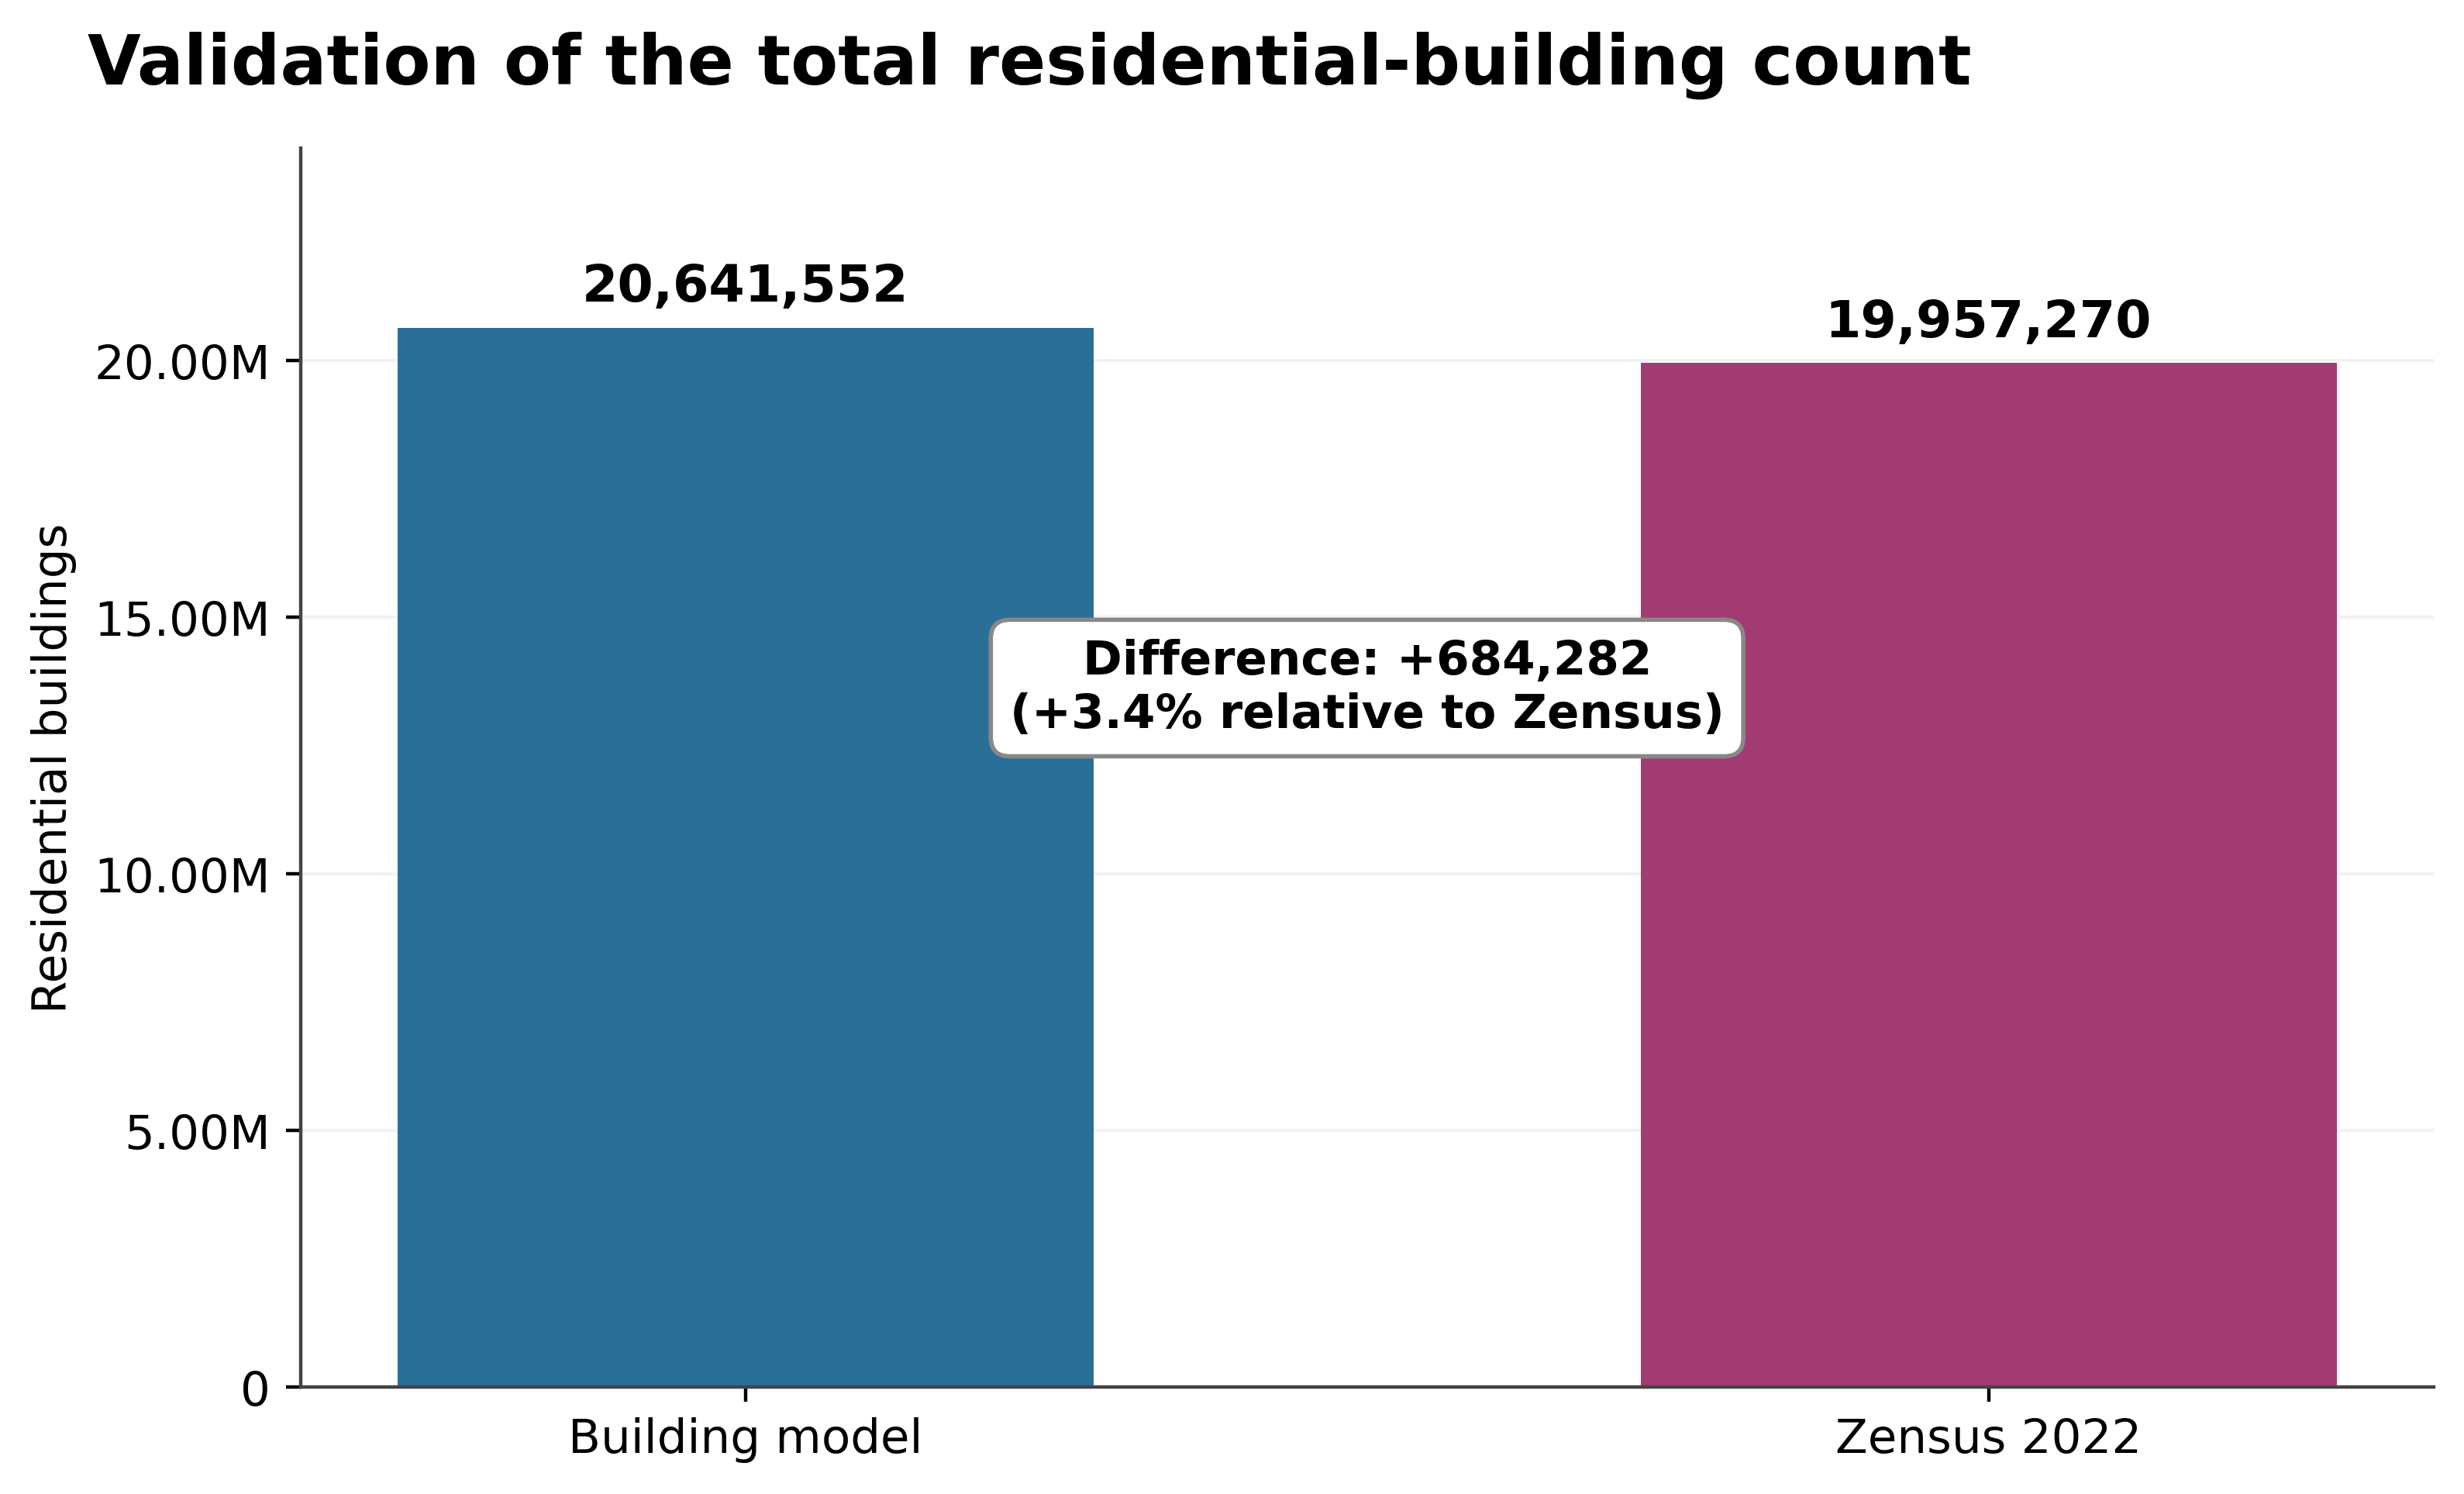

In [43]:
# Total residential validation
model_total=model_res_total
difference=model_total-zensus_total
difference_pct=difference/zensus_total*100
values=[model_total,zensus_total]

fig,ax=plt.subplots(figsize=(8.6,5.4))
fig.subplots_adjust(left=.15,right=.95,top=.90,bottom=.16)

bars=ax.bar(["Building model","Zensus 2022"],values,width=.56,
            color=[COLORS["blue"],COLORS["magenta"]])

for bar,v in zip(bars,values):
    ax.text(bar.get_x()+bar.get_width()/2,v+max(values)*.025,
            f"{v:,.0f}",ha="center",fontsize=12,fontweight="bold")

ax.text(.5,max(values)*.66,
        f"Difference: {difference:+,}\n({difference_pct:+.1f}% relative to Zensus)",
        ha="center",va="center",fontsize=11,fontweight="bold",
        bbox={"boxstyle":"round,pad=.4","facecolor":"white","edgecolor":"#888888"})

header(fig,"Validation of the total residential-building count",)

ax.set_ylabel("Residential buildings")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_:compact(v)))
ax.set_ylim(0,max(values)*1.17)
ax.grid(axis="y",alpha=.16)
ax.set_axisbelow(True)
plt.show()

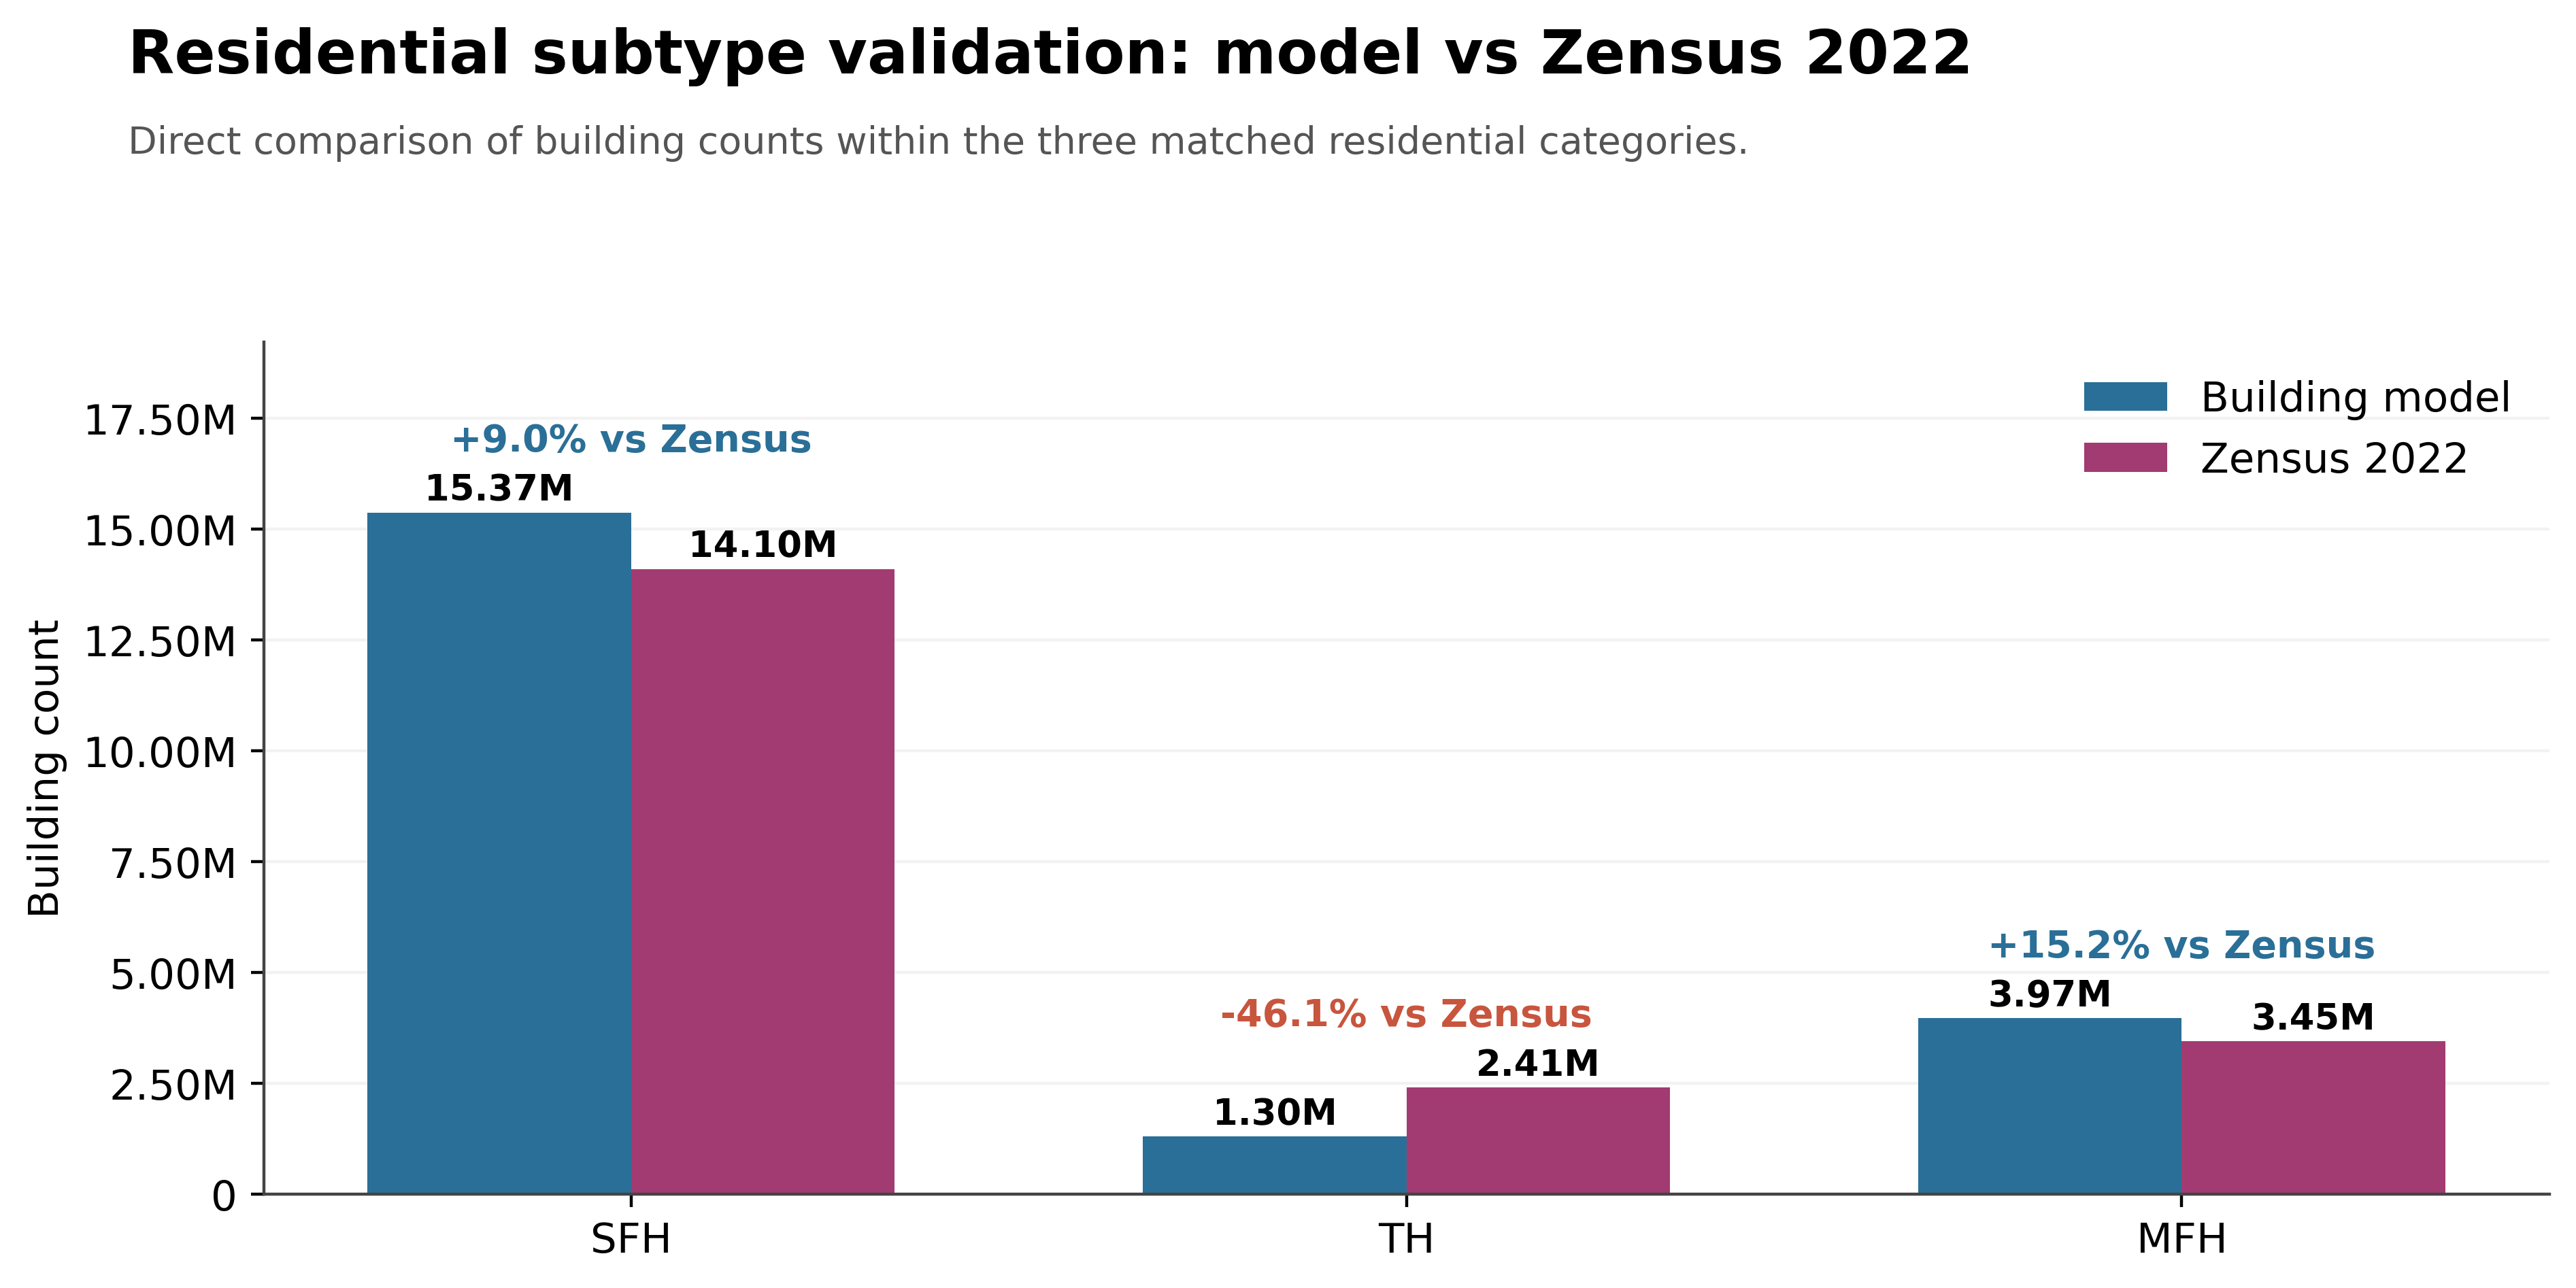

,Category,Model,Zensus,Difference,Difference vs Zensus (%)
0,SFH,"15,372,510","14,100,055","+1,272,455",+9.0%
1,TH,"1,299,133","2,410,602","-1,111,469",-46.1%
2,MFH,"3,969,909","3,446,613","+523,296",+15.2%


In [44]:
model_form={
    "SFH":model_res.get("SFH",0),
    "TH":model_res.get("TH",0),
    "MFH":model_res.get("MFH",0)
}

cats=list(model_form)
model_vals=np.array([model_form[c] for c in cats])
zensus_vals=np.array([zensus_form[c] for c in cats])
diff_pct=(model_vals-zensus_vals)/zensus_vals*100

x=np.arange(len(cats))
width=.34
max_y=max(model_vals.max(),zensus_vals.max())

fig,ax=plt.subplots(figsize=(10,5.8))
fig.subplots_adjust(left=.12,right=.96,top=.77,bottom=.23)

bars1=ax.bar(x-width/2,model_vals,width,label="Building model",color=COLORS["blue"])
bars2=ax.bar(x+width/2,zensus_vals,width,label="Zensus 2022",color=COLORS["magenta"])

for bars in [bars1,bars2]:
    for bar in bars:
        ax.text(bar.get_x()+bar.get_width()/2,bar.get_height()+max_y*.018,
                compact(bar.get_height()),ha="center",fontsize=9.5,fontweight="bold")

for i,diff in enumerate(diff_pct):
    ax.text(i,max(model_vals[i],zensus_vals[i])+max_y*.09,
            f"{diff:+.1f}% vs Zensus",ha="center",fontsize=10,
            fontweight="bold",color=COLORS["blue"] if diff>=0 else COLORS["red"])

header(fig,"Residential subtype validation: model vs Zensus 2022",
       "Direct comparison of building counts within the three matched residential categories.")

ax.set_xticks(x,["SFH","TH","MFH"])
ax.set_ylabel("Building count")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_:compact(v)))
ax.set_ylim(0,max_y*1.25)
ax.grid(axis="y",alpha=.16)
ax.legend()
ax.set_axisbelow(True)
plt.show()

validation_table=pd.DataFrame({
    "Category":cats,
    "Model":model_vals,
    "Zensus":zensus_vals,
    "Difference":model_vals-zensus_vals,
    "Difference vs Zensus (%)":diff_pct
})

validation_table.style.format({
    "Model":"{:,.0f}",
    "Zensus":"{:,.0f}",
    "Difference":"{:+,.0f}",
    "Difference vs Zensus (%)":"{:+.1f}%"
})

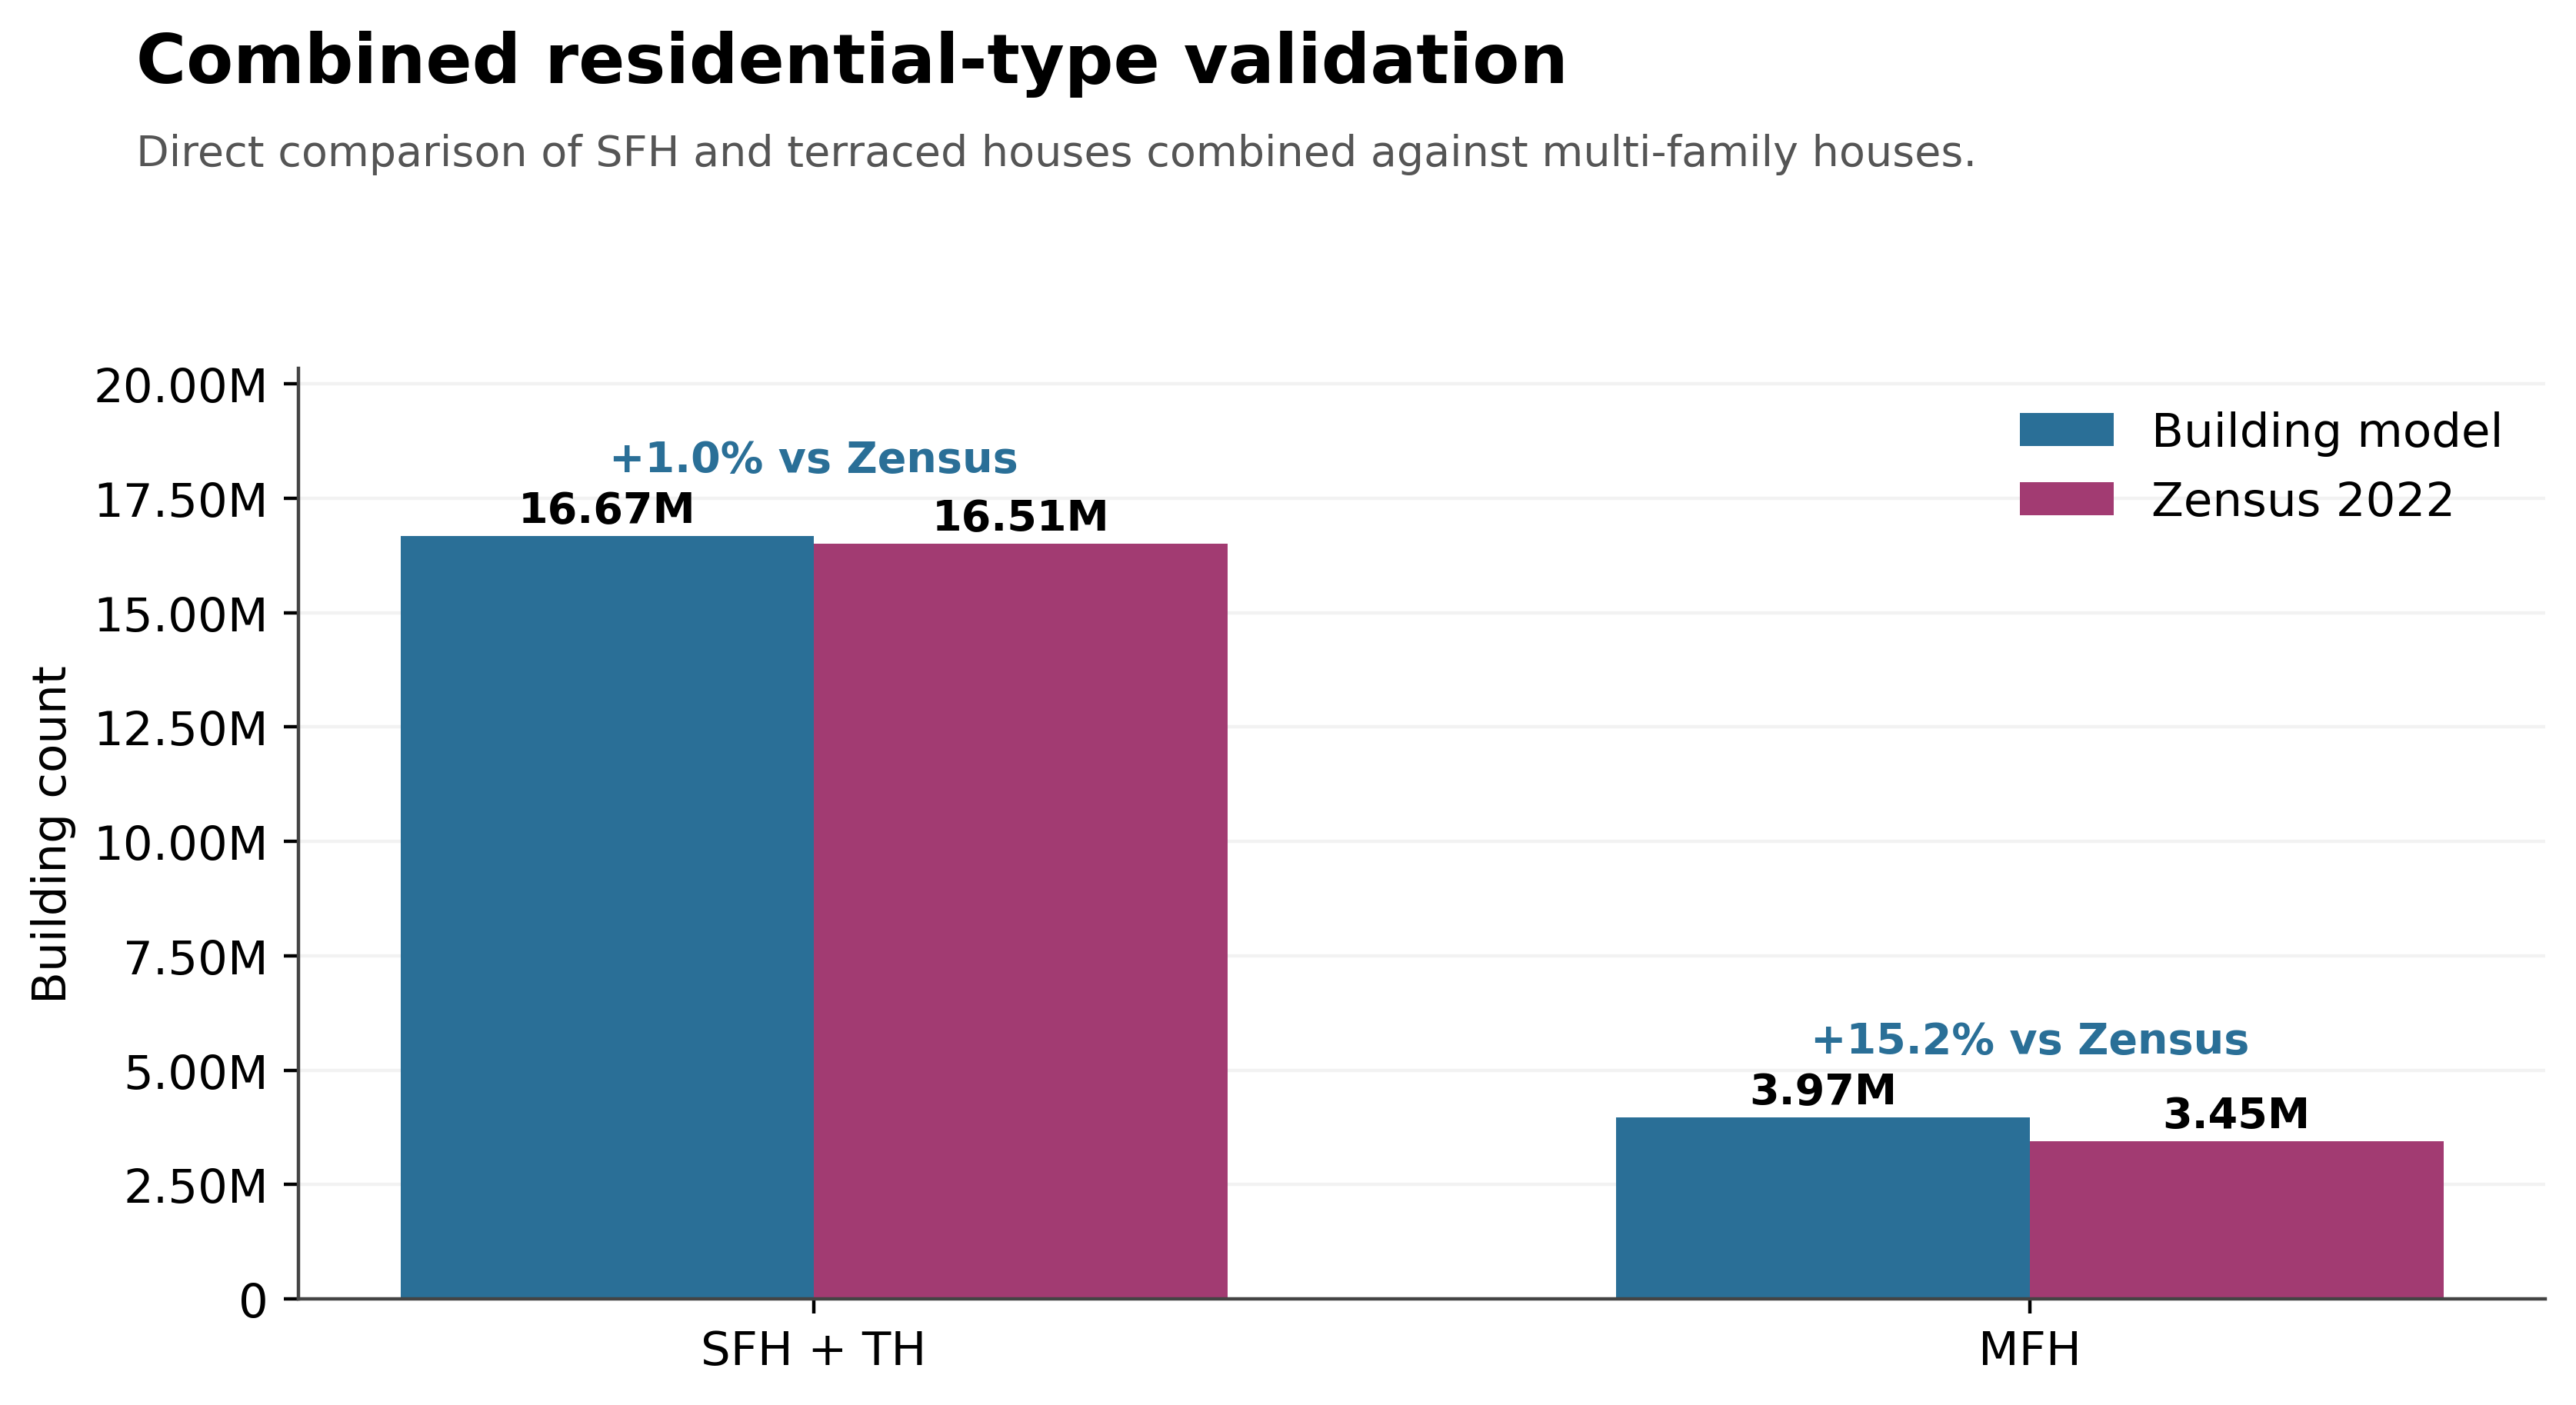

,Category,Model,Zensus,Difference,Difference vs Zensus (%)
0,Single-family + terraced,"16,671,643","16,510,657","+160,986",+1.0%
1,Multi-family,"3,969,909","3,446,613","+523,296",+15.2%


In [45]:
# Combined residential validation: SFH + TH versus MFH

model_combined={"Single-family + terraced":model_res.get("SFH",0)+model_res.get("TH",0),
    "Multi-family":model_res.get("MFH",0)}

zensus_combined={"Single-family + terraced":zensus_form["SFH"]+zensus_form["TH"],
    "Multi-family":zensus_form["MFH"]}

cats=list(model_combined)
model_vals=np.array([model_combined[c] for c in cats])
zensus_vals=np.array([zensus_combined[c] for c in cats])
diff_pct=(model_vals-zensus_vals)/zensus_vals*100
x=np.arange(len(cats))
width=.34
max_y=max(model_vals.max(),zensus_vals.max())

fig,ax=plt.subplots(figsize=(8.8,5.5))
fig.subplots_adjust(left=.13,right=.96,top=.77,bottom=.22)
bars1=ax.bar(x-width/2,model_vals,width,label="Building model",color=COLORS["blue"])
bars2=ax.bar(x+width/2,zensus_vals,width,label="Zensus 2022",color=COLORS["magenta"])

for bars in [bars1,bars2]:
    for bar in bars:
        ax.text(bar.get_x()+bar.get_width()/2,bar.get_height()+max_y*.018,
                compact(bar.get_height()),ha="center",fontsize=10,fontweight="bold")

for i,diff in enumerate(diff_pct):
    ax.text(i,max(model_vals[i],zensus_vals[i])+max_y*.085,
            f"{diff:+.1f}% vs Zensus",ha="center",fontsize=10,
            fontweight="bold",color=COLORS["blue"] if diff>=0 else COLORS["red"])

header(fig,"Combined residential-type validation",
       "Direct comparison of SFH and terraced houses combined against multi-family houses.")

ax.set_xticks(x,["SFH + TH","MFH"])
ax.set_ylabel("Building count")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_:compact(v)))
ax.set_ylim(0,max_y*1.22)
ax.grid(axis="y",alpha=.16)
ax.legend()
ax.set_axisbelow(True)
plt.show()

combined_validation=pd.DataFrame({
    "Category":cats,
    "Model":model_vals,
    "Zensus":zensus_vals,
    "Difference":model_vals-zensus_vals,
    "Difference vs Zensus (%)":diff_pct
})

combined_validation.style.format({
    "Model":"{:,.0f}",
    "Zensus":"{:,.0f}",
    "Difference":"{:+,.0f}",
    "Difference vs Zensus (%)":"{:+.1f}%"
})

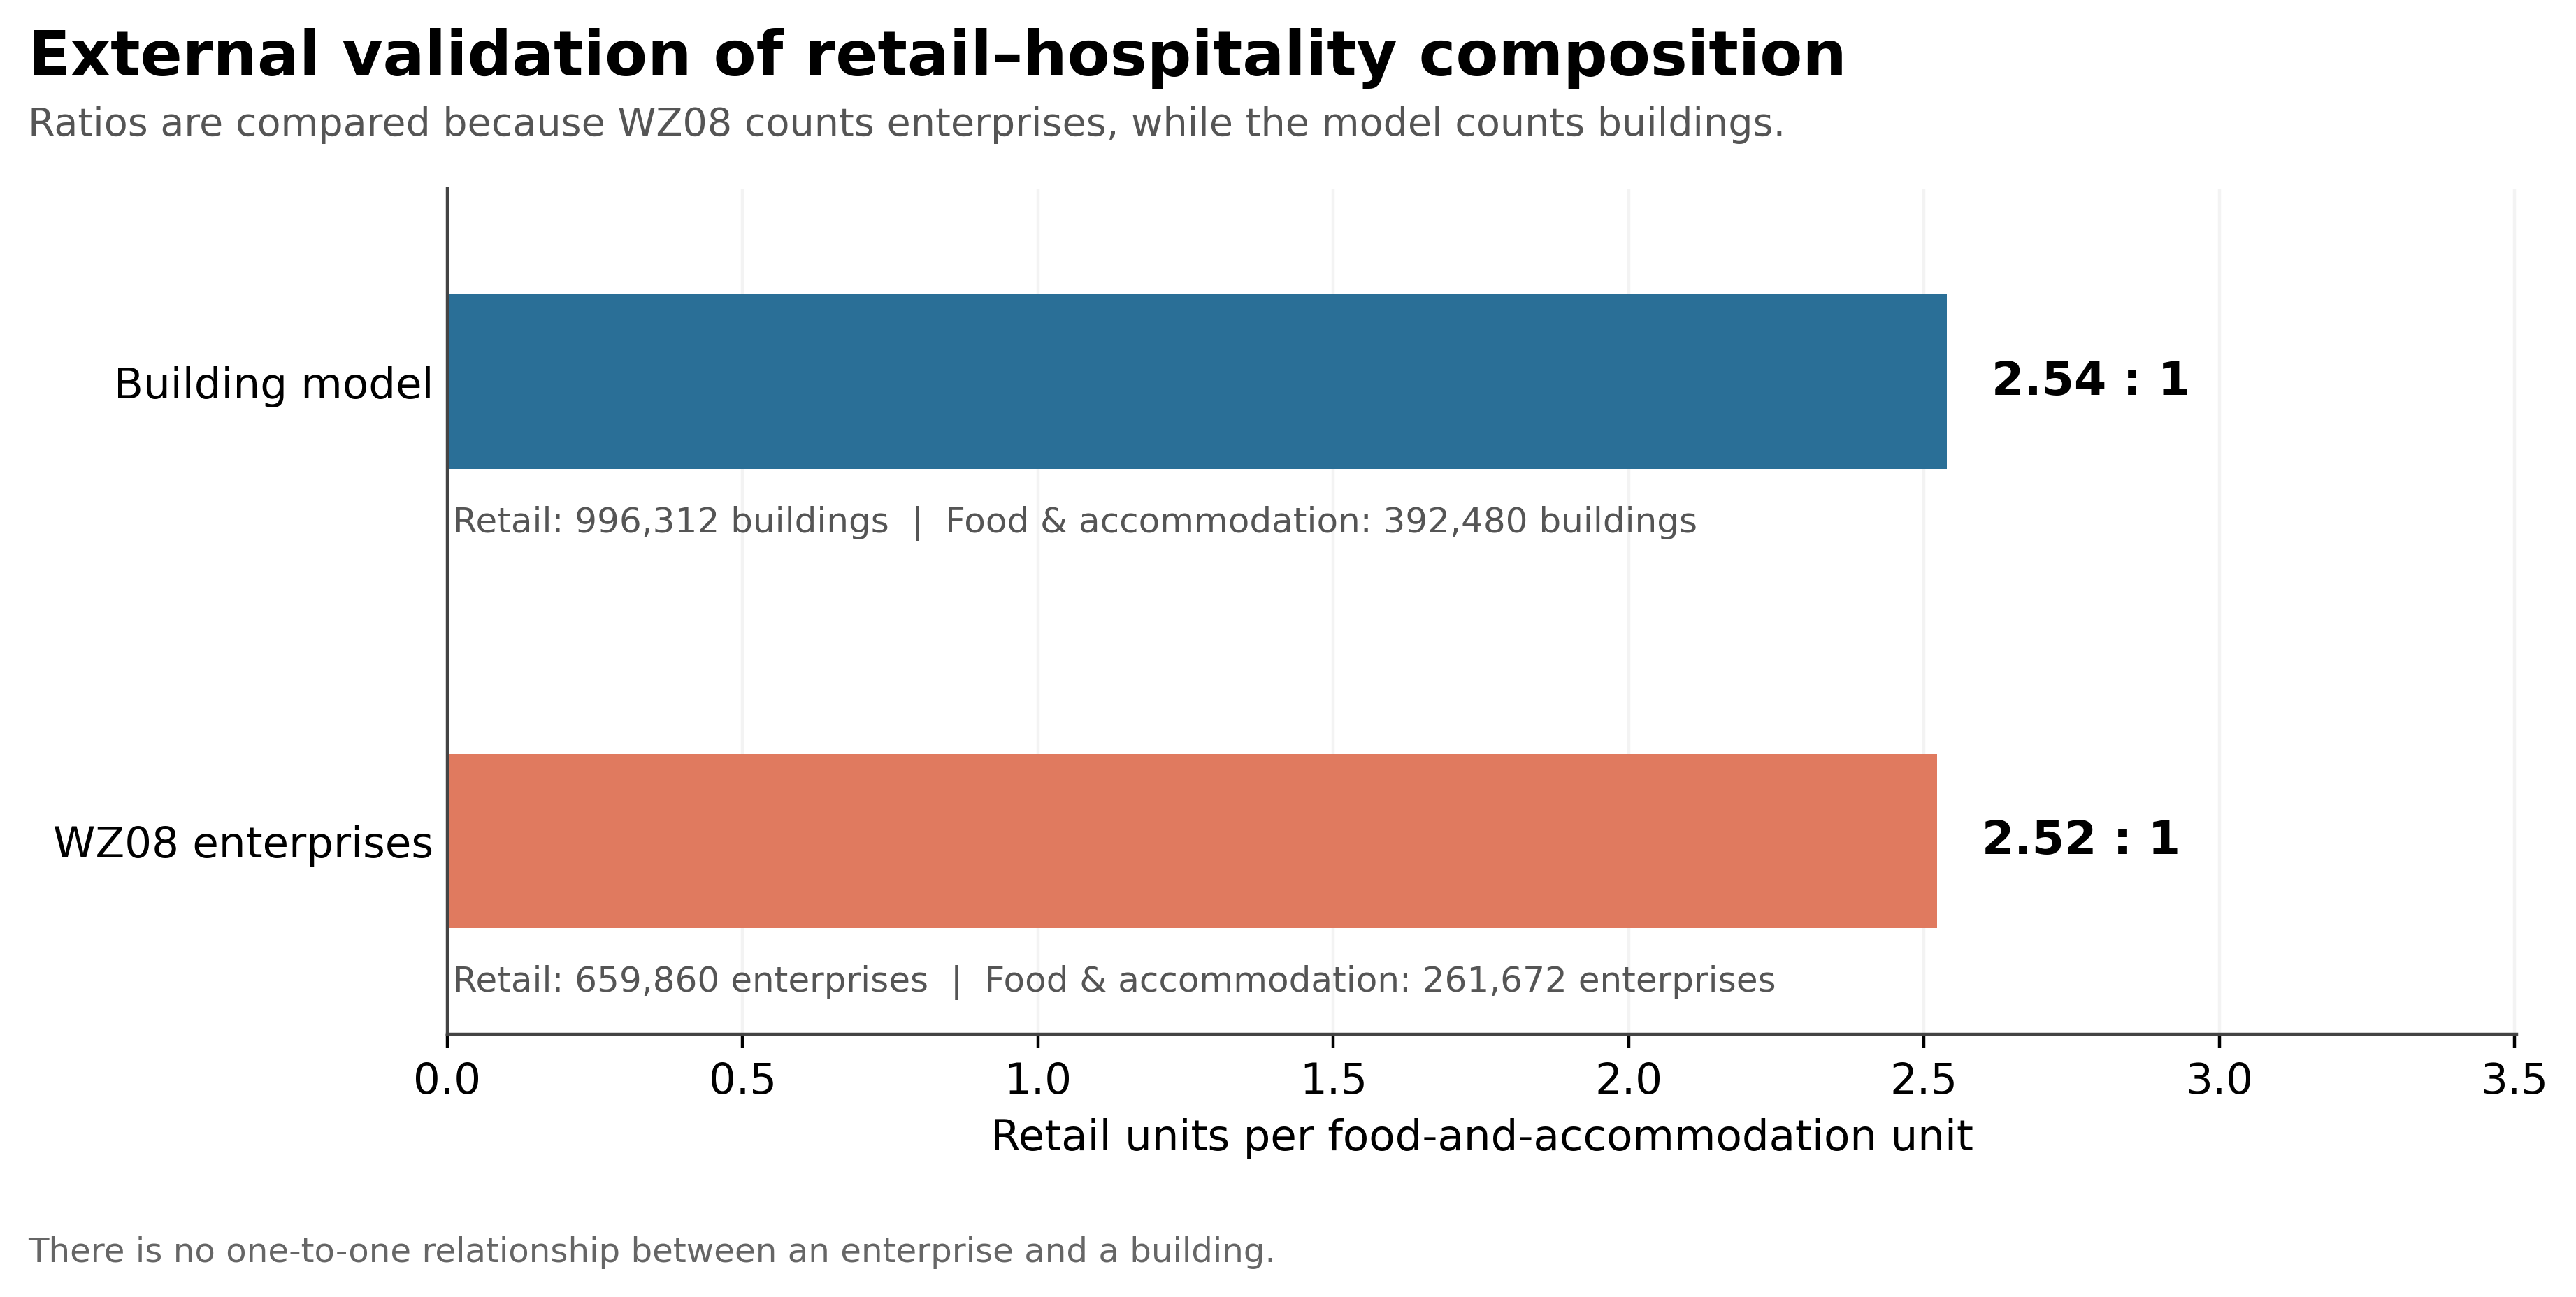

In [47]:
model_retail = (
    model_comm.get("retail", 0)
    )

model_hospitality = (
    model_comm.get("food_drink", 0)
    + model_comm.get("accommodation", 0)
   )
wz_retail=wz08["G_wholesale_retail"]
wz_hospitality=wz08["I_accommodation_food"]


model_ratio_retail=model_retail/model_hospitality
wz_ratio_retail=wz_retail/wz_hospitality

ratio_chart(
    "External validation of retail–hospitality composition",
    "Ratios are compared because WZ08 counts enterprises, while the model counts buildings.",
    ["Building model","WZ08 enterprises"],
    [model_ratio_retail,wz_ratio_retail],
    [
        f"Retail: {model_retail:,} buildings  |  Food & accommodation: {model_hospitality:,} buildings",
        f"Retail: {wz_retail:,} enterprises  |  Food & accommodation: {wz_hospitality:,} enterprises"
    ],
    "Retail units per food-and-accommodation unit",
    "There is no one-to-one relationship between an enterprise and a building."
)

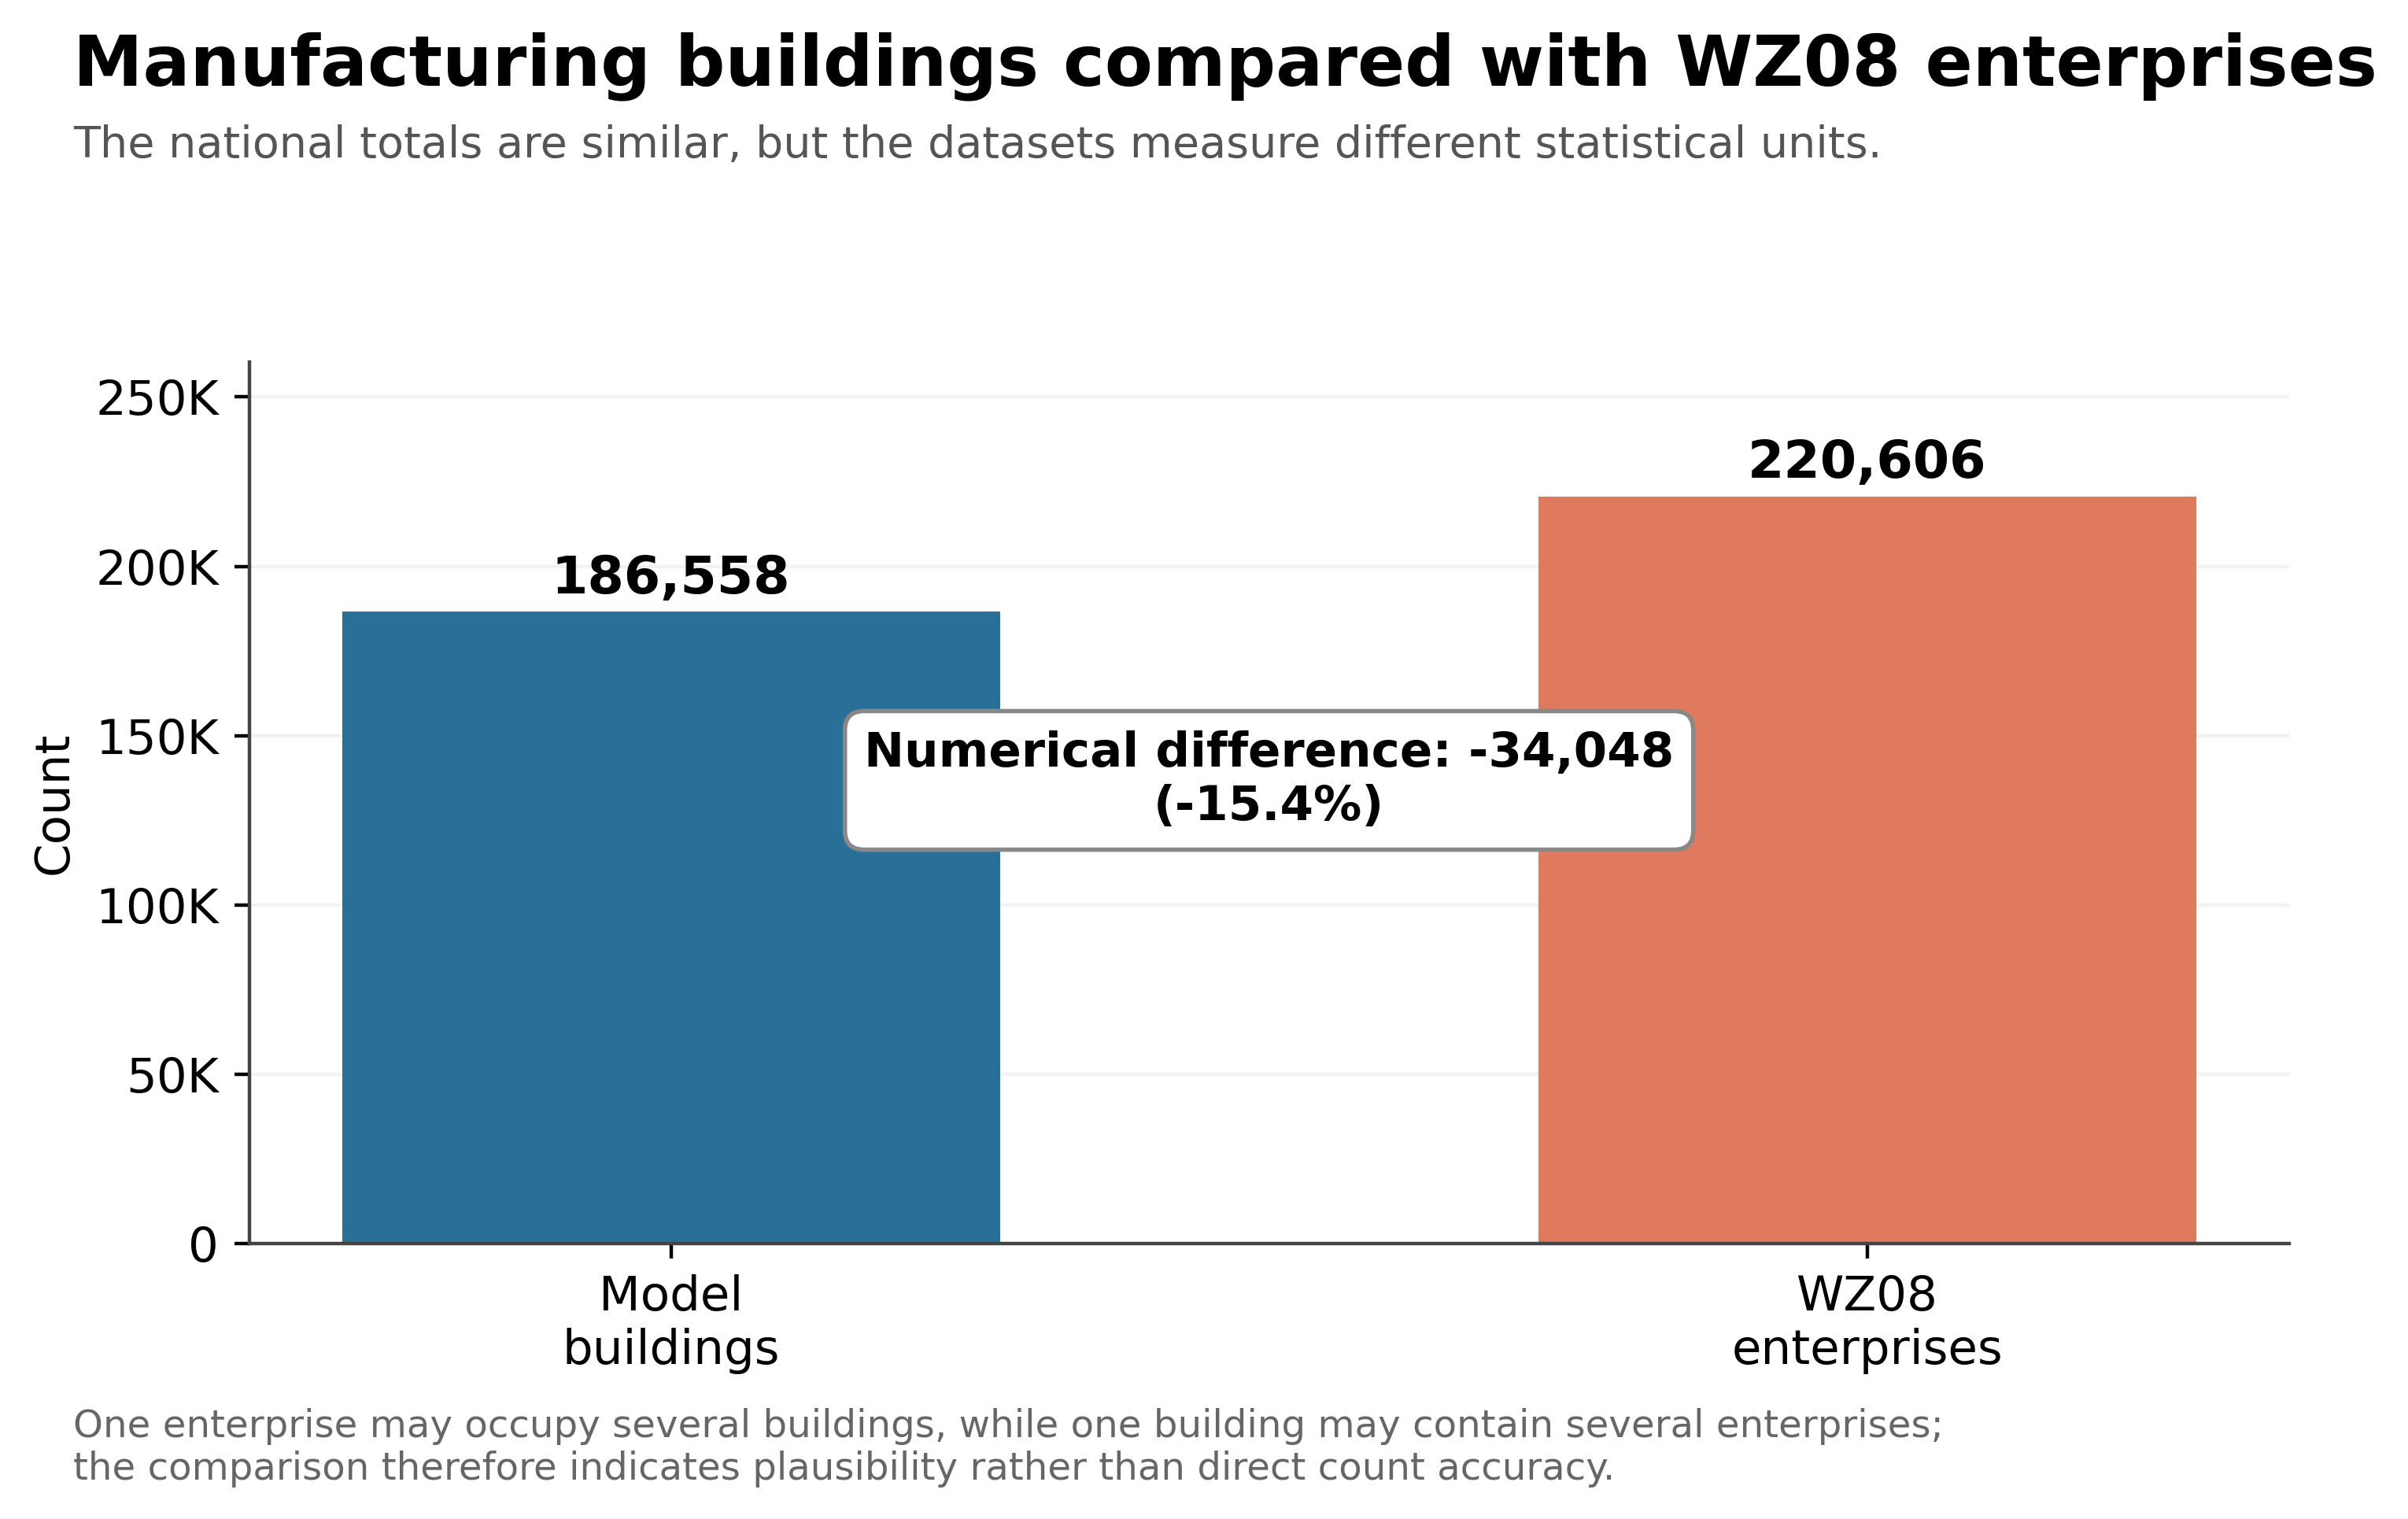

In [48]:
model_manufacturing=model_ind.get("manufacturing",0)
wz_manufacturing=wz08["C_manufacturing"]

values=[model_manufacturing,wz_manufacturing]
labels=["Model\nbuildings","WZ08\nenterprises"]
difference=model_manufacturing-wz_manufacturing
difference_pct=difference/wz_manufacturing*100

fig,ax=plt.subplots(figsize=(8,5))
fig.subplots_adjust(left=.14,right=.95,top=.76,bottom=.20)

bars=ax.bar(labels,values,width=.55,color=[COLORS["blue"],COLORS["orange"]])

for bar,value in zip(bars,values):
    ax.text(bar.get_x()+bar.get_width()/2,value+max(values)*.025,
            f"{value:,}",ha="center",fontsize=12,fontweight="bold")

ax.text(.5,max(values)*.62,
        f"Numerical difference: {difference:+,}\n({difference_pct:+.1f}%)",
        ha="center",va="center",fontsize=11,fontweight="bold",
        bbox={"boxstyle":"round,pad=.4","facecolor":"white","edgecolor":"#888888"})

header(fig,
       "Manufacturing buildings compared with WZ08 enterprises",
       "The national totals are similar, but the datasets measure different statistical units.")

ax.set_ylabel("Count")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_:compact(v)))
ax.set_ylim(0,max(values)*1.18)
ax.grid(axis="y",alpha=.16)
ax.set_axisbelow(True)

fig.text(.07,.05,
         "One enterprise may occupy several buildings, while one building may contain several enterprises; "
         "\nthe comparison therefore indicates plausibility rather than direct count accuracy.",
         fontsize=8.7,color="#666666")

plt.show()

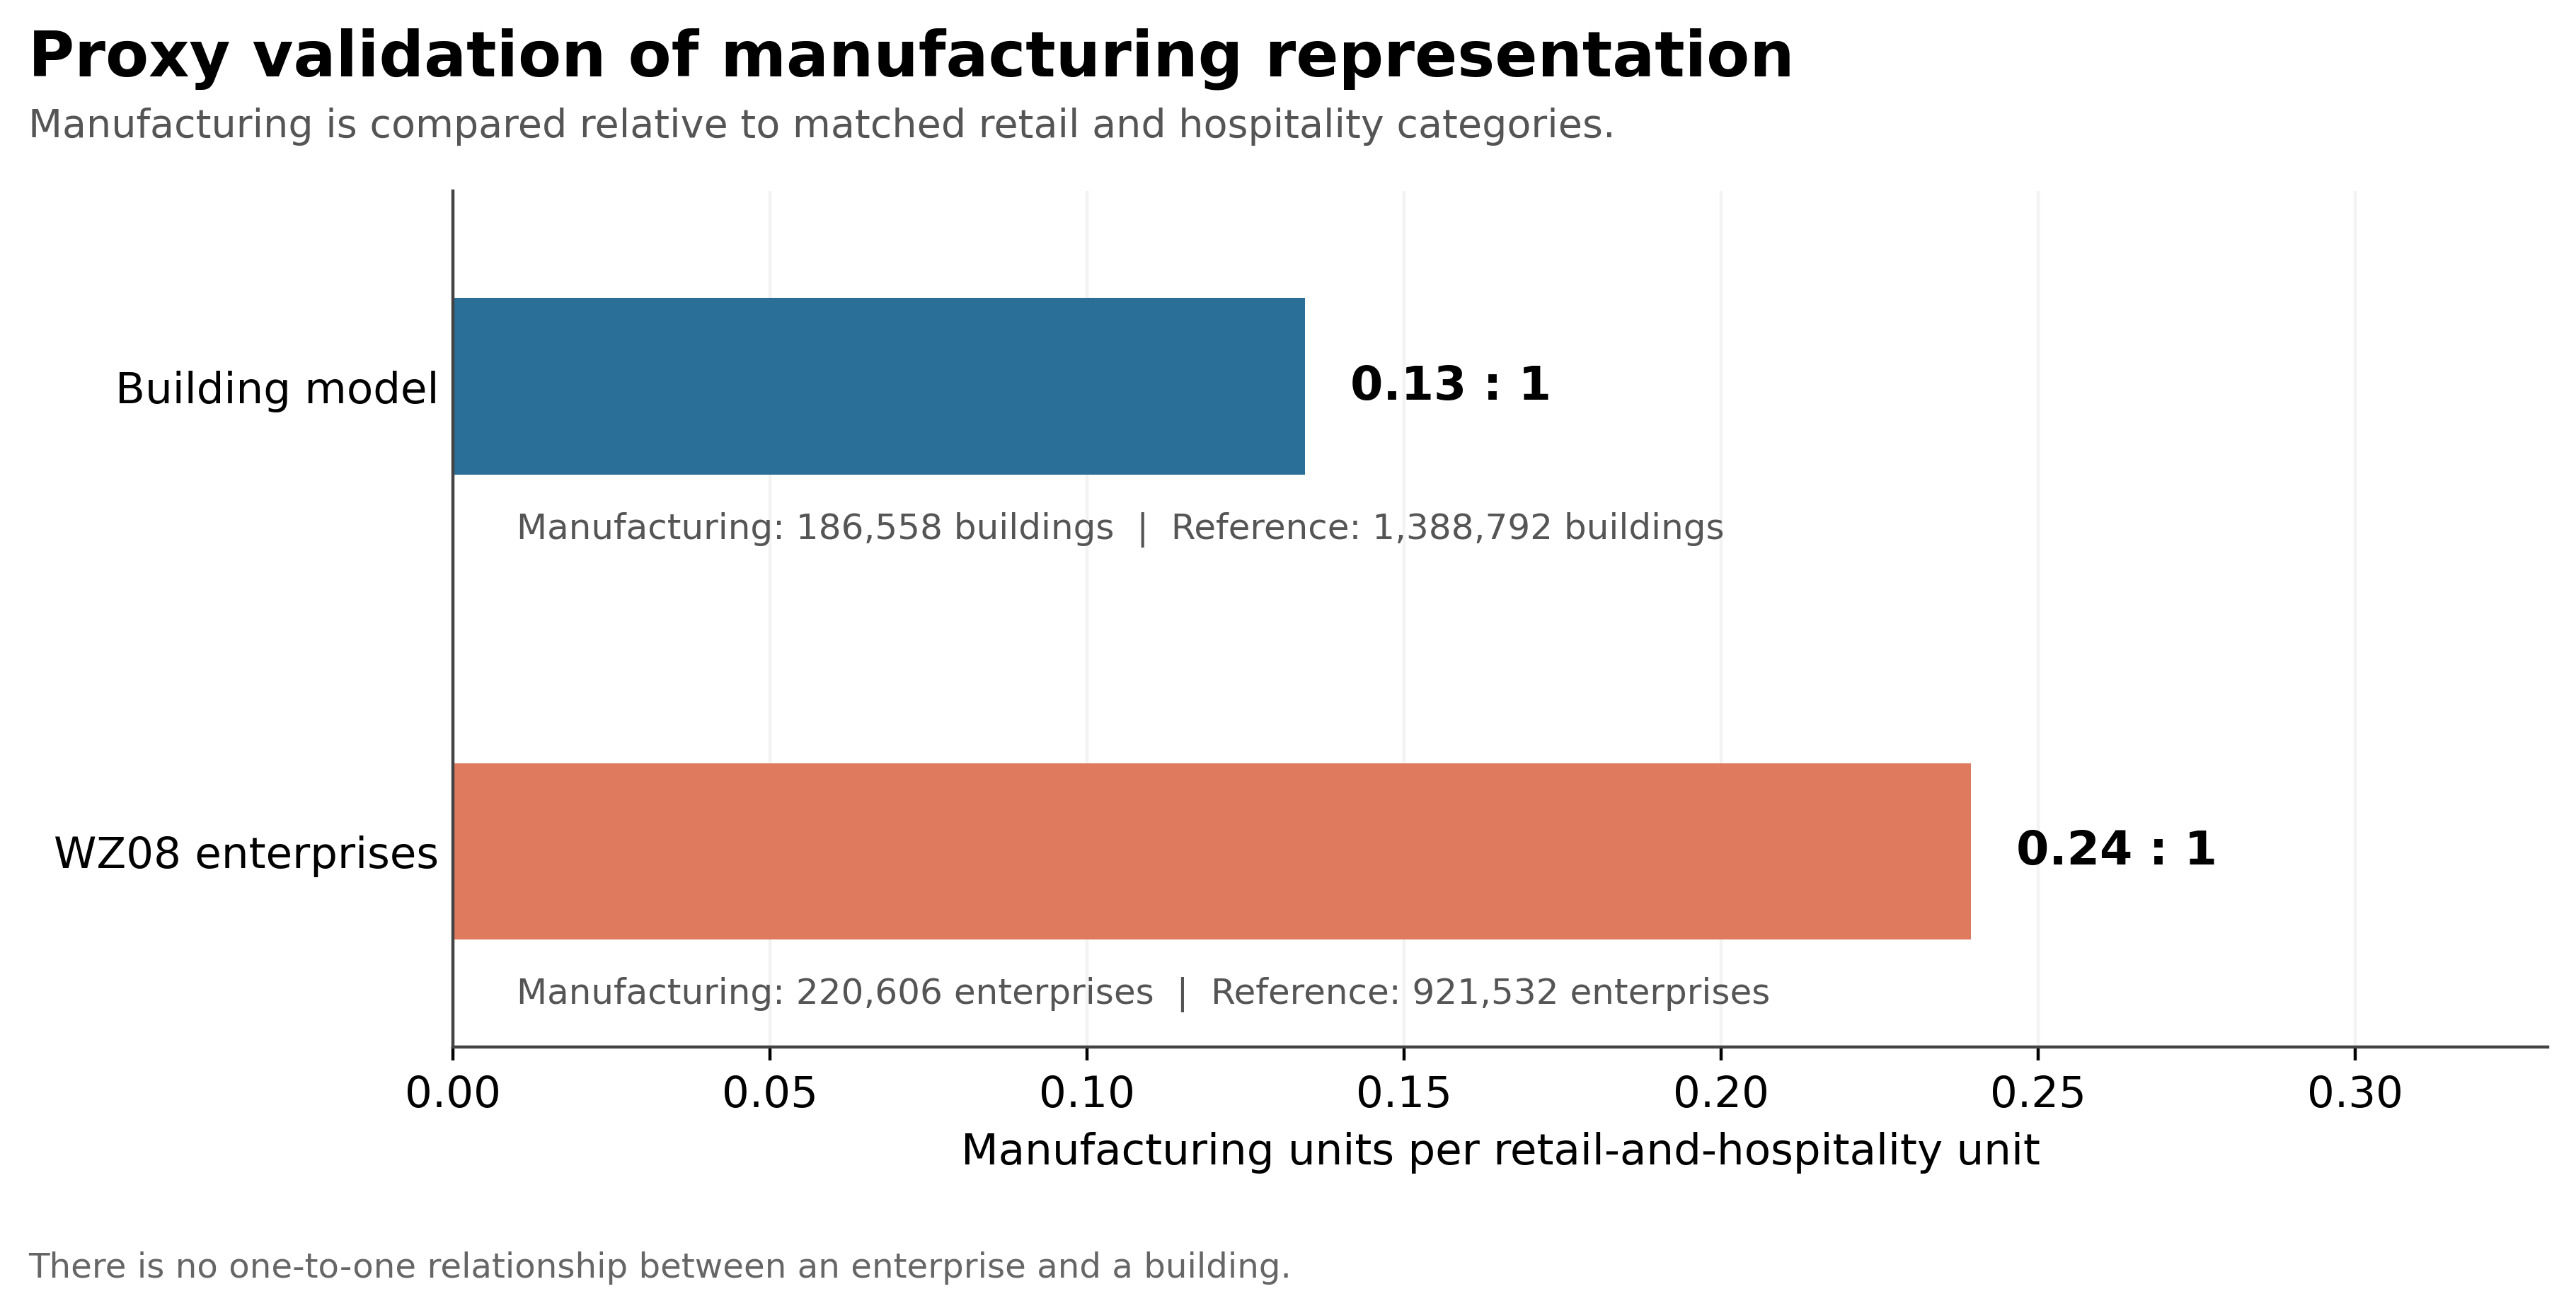

In [51]:
model_manufacturing=model_ind.get("manufacturing",0)
model_reference=model_retail+model_hospitality
wz_manufacturing=wz08["C_manufacturing"]
wz_reference=wz_retail+wz_hospitality

model_ratio_manufacturing=model_manufacturing/model_reference
wz_ratio_manufacturing=wz_manufacturing/wz_reference

ratio_chart(
    "Proxy validation of manufacturing representation",
    "Manufacturing is compared relative to matched retail and hospitality categories.",
    ["Building model","WZ08 enterprises"],
    [model_ratio_manufacturing,wz_ratio_manufacturing],
    [
        f"Manufacturing: {model_manufacturing:,} buildings  |  Reference: {model_reference:,} buildings",
        f"Manufacturing: {wz_manufacturing:,} enterprises  |  Reference: {wz_reference:,} enterprises"
    ],
    "Manufacturing units per retail-and-hospitality unit",
    "There is no one-to-one relationship between an enterprise and a building."
)

In [52]:
# ============================================================
# UPDATED: Non-residential proportional check — office added
# ============================================================
# Office buildings typically house several WZ08 sectors, not just one:
# K (finance/insurance), M (professional/scientific/technical),
# N (administrative/support), J (info/communication) all commonly sit in office buildings.
wz08_office_proxy = {
    "J_info_comm": 155067,
    "K_finance_insurance": 95842,
    "M_professional_scientific": 553376,
    "N_admin_support": 270471,
}
wz08_office_total = sum(wz08_office_proxy.values())

print("=== Office proportional check ===")
print(f"Model office buildings: {model_comm.get('office', 0):,}")
print(f"WZ08 office-type enterprises (J+K+M+N): {wz08_office_total:,}  "
      f"(again: enterprises, not buildings — many share one office building)")

model_office_share = model_comm.get('office', 0) / sum(model_comm.values()) * 100
wz_office_share = wz08_office_total / (wz08_office_total + wz08["G_wholesale_retail"] + wz08["I_accommodation_food"] + wz08["C_manufacturing"]) * 100
print(f"Model office share of commercial+industrial+office pool: {model_office_share:.1f}%")
print(f"WZ08  office-sector share of matched pool: {wz_office_share:.1f}%")


=== Office proportional check ===
Model office buildings: 266,130
WZ08 office-type enterprises (J+K+M+N): 1,074,756  (again: enterprises, not buildings — many share one office building)
Model office share of commercial+industrial+office pool: 16.0%
WZ08  office-sector share of matched pool: 48.5%


In [ ]:
gdf_parents_final.shape

(565557, 7)